In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

# Introducción breve a matplotlib y seaborn

Vamos a mostrar como hacer una serie de gráficos básicos con Matplotlib y Seaborn en Python.
Para esto usaremos una base de datos económicos de EE.UU. con series de tiempo.

In [2]:
economics = pd.read_csv('../data/economics.csv', parse_dates=[0])
economics.head()

,date,pce,pop,psavert,uempmed,unemploy
0,1967-07-01,506.7,198712.0,12.6,4.5,2944
1,1967-08-01,509.8,198911.0,12.6,4.7,2945
2,1967-09-01,515.6,199113.0,11.9,4.6,2958
3,1967-10-01,512.2,199311.0,12.9,4.9,3143
4,1967-11-01,517.4,199498.0,12.8,4.7,3066


Comencemos una gráfica de líneas de la tasa de desempleo en el tiempo:

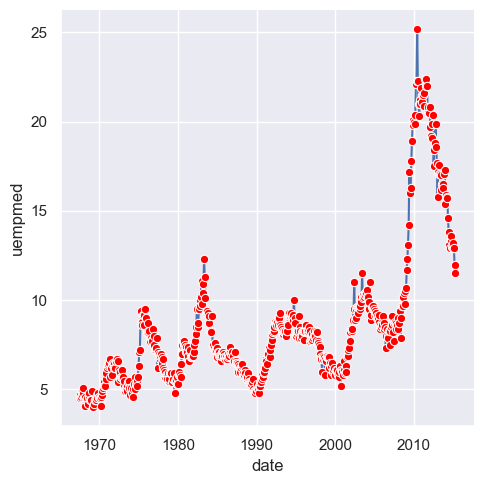

In [3]:
#economics.plot(x='date', y='uempmed', style='-o', ms=2);
#plt.plot(economics.date, economics.uempmed, '-o', mfc='red', mec='red', ms=2)
#plt.xlabel('date')
#plt.ylabel('uempmed');
sns.relplot(data=economics, x='date', y='uempmed', kind='line', marker='o', mfc='red');

# Visualizando distribuciones

Es fácil falsear una estadística de resumen, pero es mucho más difícil falsear una distribución. Es en la forma de los datos
que podemos aprender más sobre un fenómeno. Tanto las variables discretas como las continuas tienen distribuciones
que pueden visualizarse. Utilizando un conjunto de datos transversales de las características económicas de n = 3137 condados de EE.UU.
(cty), revisaremos algunas opciones de gráficos para distintos tipos de datos.

In [4]:
cty = pd.read_csv('../data/country_compare.csv')
cty.head()

,region,fips,state,name,ba,all.emp,pct.tech,est,pov,inc
0,South,1001,AL,Autauga County,24.593,10790,0.398517,0.235018,14.0,54487.0
1,South,1003,AL,Baldwin County,29.547,61341,0.386365,0.305635,12.0,56460.0
2,South,1005,AL,Barbour County,12.868,6857,0.000000,0.000000,30.0,32884.0
3,South,1007,AL,Bibb County,12.000,3387,0.000000,0.000000,20.0,43079.0
4,South,1009,AL,Blount County,13.050,6286,0.302259,0.296296,14.0,47213.0


In [5]:
cty.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3137 entries, 0 to 3136
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   region    3137 non-null   object 
 1   fips      3137 non-null   int64  
 2   state     3137 non-null   object 
 3   name      3137 non-null   object 
 4   ba        3137 non-null   float64
 5   all.emp   3137 non-null   int64  
 6   pct.tech  3137 non-null   float64
 7   est       3137 non-null   float64
 8   pov       3137 non-null   float64
 9   inc       3137 non-null   float64
dtypes: float64(5), int64(2), object(3)
memory usage: 245.2+ KB


## Distribuciones discretas, variables categóricas

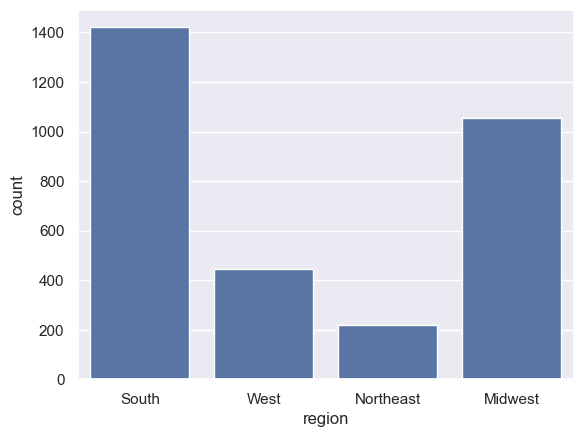

In [6]:
sns.countplot(data=cty, x='region');

In [7]:
regional = cty.groupby('region')['all.emp'].agg(['count', 'sum', 'mean', 'median']).reset_index()
regional

,region,count,sum,mean,median
0,Midwest,1054,27726903,26306.359583,5301.5
1,Northeast,217,23171173,106779.599078,30183.0
2,South,1421,43318966,30484.845883,6115.0
3,West,445,27372244,61510.660674,5534.0


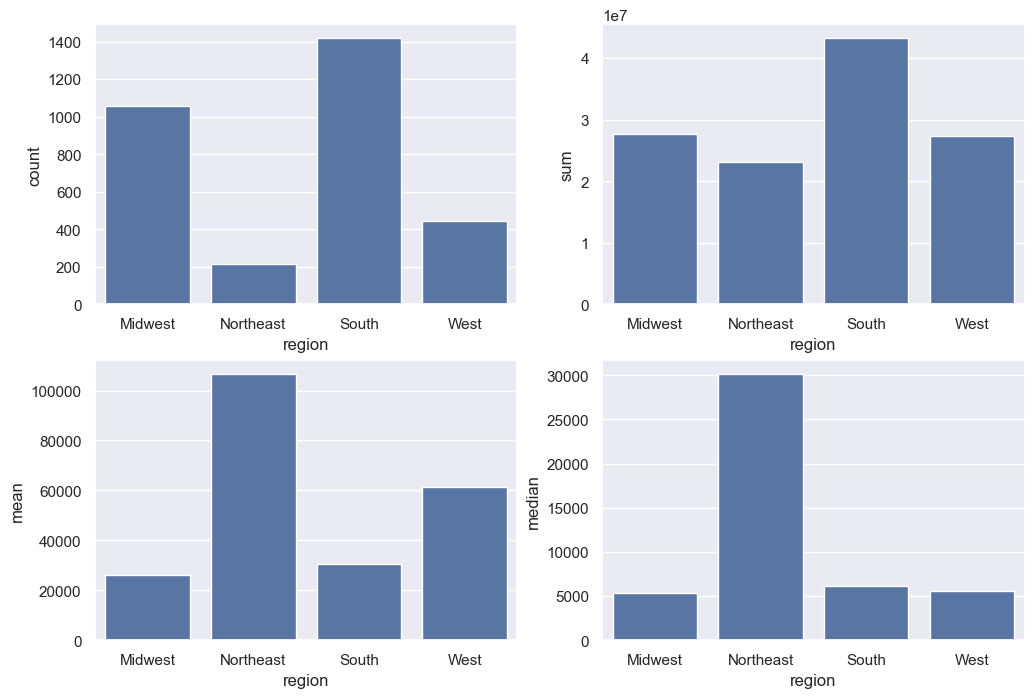

In [8]:
fig, ax = plt.subplots(2, 2, figsize=(12,8))

sns.barplot(data=regional, x='region', y='count', ax=ax[0, 0])
sns.barplot(data=regional, x='region', y='sum', ax=ax[0, 1])
sns.barplot(data=regional, x='region', y='mean', ax=ax[1, 0])
sns.barplot(data=regional, x='region', y='median', ax=ax[1, 1]);

¿Qué pasa si tenemos muchas variables?

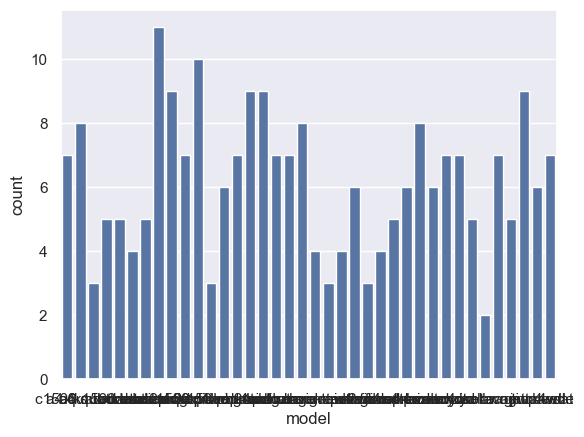

In [9]:
url = "https://github.com/byuidatascience/data4python4ds/raw/master/data-raw/mpg/mpg.csv"
mpg = pd.read_csv(url)
sns.countplot(data = mpg, x = 'model');

Podemos re-clasificar clases con pocas observaciones en una nueva variable y gráficar esa

In [10]:
many_models = mpg.groupby('model').agg(n=('hwy', 'size')).reset_index()
many_models['many'] = [
    'other' if n < 8 else model
    for n, model in zip(many_models.n, many_models.model)
]
many_models.head()

,model,n,many
0,4runner 4wd,6,other
1,a4,7,other
2,a4 quattro,8,a4 quattro
3,a6 quattro,3,other
4,altima,6,other


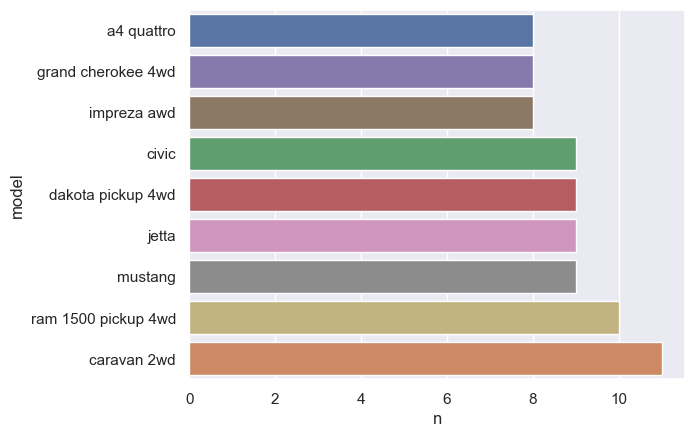

In [11]:
sns.barplot(
    data=many_models.query("many != 'other'"),
    y='model',
    x='n',
    order=many_models.query("many != 'other'").sort_values('n').model,
    hue='model'
);

### Ejercicio:
Usa la base de datos a continuación y haz una gráfica de la variación de las variables clarity y color.

¿Qué crees que funciona mejor para mostrar la variación de estas dos variables?

In [12]:
url = "https://github.com/byuidatascience/data4python4ds/raw/master/data-raw/diamonds/diamonds.csv"
diamonds = pd.read_csv(url)
# Checa si las variables categoricas son `categoricas`
diamonds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


In [13]:
diamonds['cut'] = pd.Categorical(
    diamonds.cut,
    ordered=True,
    categories=["Fair", "Good", "Very Good", "Premium", "Ideal" ]
)
diamonds['color'] = pd.Categorical(
    diamonds.color,
    ordered = True,
    categories = ["D", "E", "F", "G", "H", "I", "J"]
)
diamonds['clarity'] = pd.Categorical(
    diamonds.clarity,
    ordered=True,
    categories=["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"]
)

## Distribuciones continuas (variables numéricas)

Los histogramas son ideales para exponer la forma de una distribución continua. Estos
se parecen a los gráficos de barras con una pequeña diferencia: en lugar de representar la frecuencia de las categorías en variables discretas, los histogramas convierten una variable continua en una serie de intervalos de igual tamaño. La altura de un intervalo representa el número de observaciones que caen dentro del rango del intervalo.
El caso ideal para cualquier variable es la presencia de señal. En un histograma, un claro indicio de señal es la existencia de un pico, una tendencia central en la que es más probable que se sitúe la media o la mediana. Un error común es pensar que los datos continuos siempre siguen una curva normal (distribución de Gauss). En la mayoría de los casos, muy pocas variables en la naturaleza siguen realmente este estereotipo de datos y cuando los datos no siguen este patrón esperado, es difícil de entender para muchos. Por ejemplo, el porcentaje de un condado que tiene estudios universitarios (ba) no sigue una curva simétrica.

In [14]:
cty.head()

,region,fips,state,name,ba,all.emp,pct.tech,est,pov,inc
0,South,1001,AL,Autauga County,24.593,10790,0.398517,0.235018,14.0,54487.0
1,South,1003,AL,Baldwin County,29.547,61341,0.386365,0.305635,12.0,56460.0
2,South,1005,AL,Barbour County,12.868,6857,0.000000,0.000000,30.0,32884.0
3,South,1007,AL,Bibb County,12.000,3387,0.000000,0.000000,20.0,43079.0
4,South,1009,AL,Blount County,13.050,6286,0.302259,0.296296,14.0,47213.0


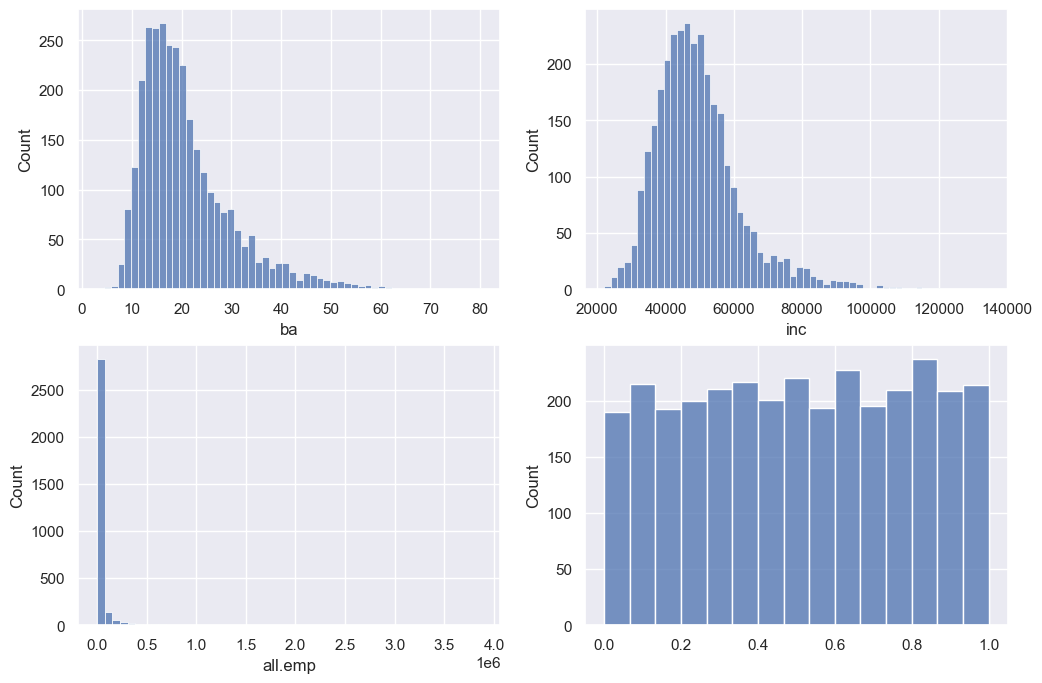

In [15]:
fig, ax = plt.subplots(2, 2, figsize=(12,8))

sns.histplot(data=cty, x='ba', ax=ax[0, 0])
sns.histplot(data=cty, x='inc', ax=ax[0, 1])
sns.histplot(data=cty, x='all.emp', ax=ax[1, 0], bins=50)
sns.histplot(x=np.random.uniform(size=cty.shape[0]), ax=ax[1, 1]);

La primera figura muestra el porcentaje de un condado con estudios universitarios (ba), que alcanza un máximo del 18% y tiene una cola derecha ligeramente más larga que la cola izquierda. La renta media del condado (inc) presenta una forma de distribución similar. Ambas son variables que se comportan bastante bien. Sin embargo, el empleo total (all.emp) está muy sesgado. Cuando se presente una distribución sesgada, dedique algún tiempo a investigar las observaciones de la cola larga para entender en qué se diferencian de los picos. En algunos casos, estas observaciones periféricas tienen una explicación razonable. En estos gráficos, por ejemplo, las colas están formadas por condados con las ciudades más grandes de Estados Unidos, como el condado de Cook (Chicago), Los Ángeles, los Cinco Barrios de Nueva York, entre otras grandes áreas metropolitanas. De hecho, el 20% de los condados más poblados concentran el 85.9% del empleo del país. Alternativamente, si no hay un patrón discernible, tal vez estas observaciones sean anomalías o valores atípicos.

Los tres primeros gráficos ilustran la presencia de una señal, es decir, una tendencia central clara. ¿Qué aspecto tiene un histograma cuando una variable carece de señal? Quizás la causa más común es una distribución uniforme aleatoria. Cada casilla tiene aproximadamente la misma altura. Si extrajéramos aleatoriamente una observación, existe la misma probabilidad de que pudiera originarse en cualquier punto de la distribución. Por el contrario, la mayoría de las observaciones tienden a agruparse alrededor del pico en los tres primeros gráficos, por lo que hay una mayor probabilidad de que una observación extraída al azar esté más cerca de esa región.

Para muestras pequeñas, los histogramas aparecen dentados y pueden resultar difíciles de interpretar. Una alternativa elegante es el gráfico "kernel density". El gráfico se basa en la estimación de la densidad para calcular la probabilidad de observar un valor determinado basándose en la proximidad a todos los puntos dentro de un ancho de banda. El ancho de banda es un tamaño de ventana que indica la cantidad de una variable que debe incluirse en el cálculo, donde los anchos de banda mayores producen gráficos más suaves con menos ruido, mientras que los anchos de banda menores producen resultados más volátiles. Esto implica que la forma de la curva puede cambiar si modificamos el ancho de banda -- el patrón es una aproximación que puede manipularse.

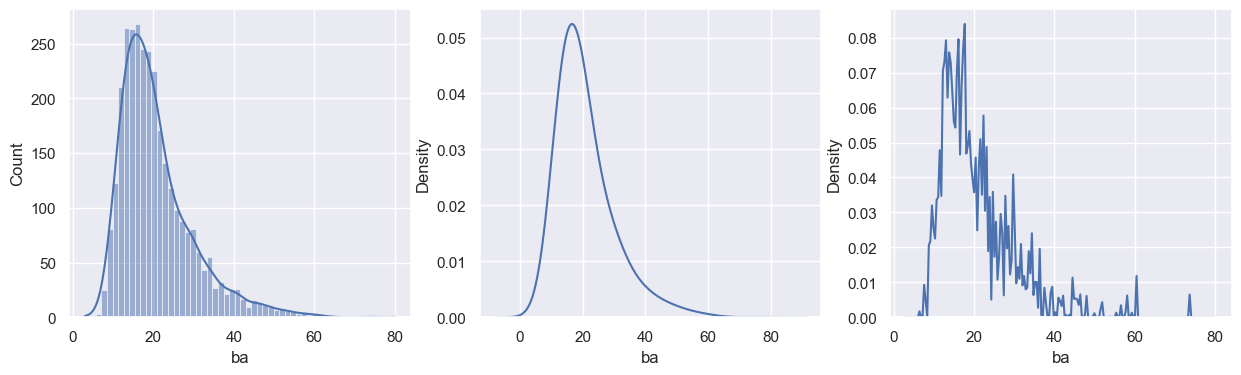

In [16]:
fig, ax = plt.subplots(1, 3, figsize=(15,4))

sns.histplot(data=cty, x='ba', ax=ax[0], kde=True)
sns.kdeplot(data=cty, x='ba', ax=ax[1], bw_adjust=2)
sns.kdeplot(data=cty, x='ba', ax=ax[2], bw_adjust=0.01);

Al incorporar variables discretas, podemos enriquecer de las variables continuas.

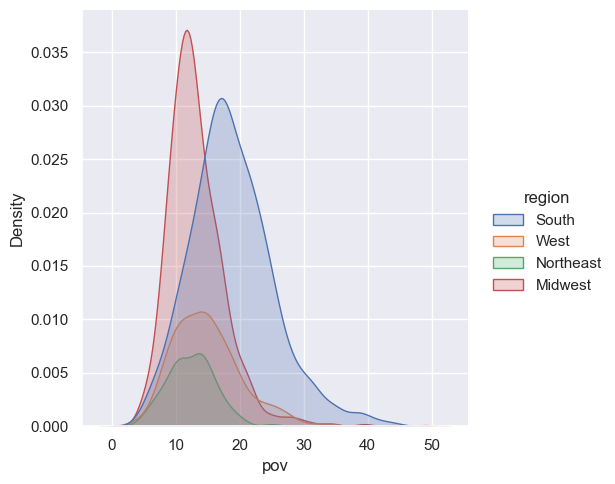

In [162]:
sns.displot(data=cty, x='pov', hue='region', kind='kde', fill=True)
#sns.displot(data=cty, x='pov', col='region', hue='region', kind='hist', kde=True);

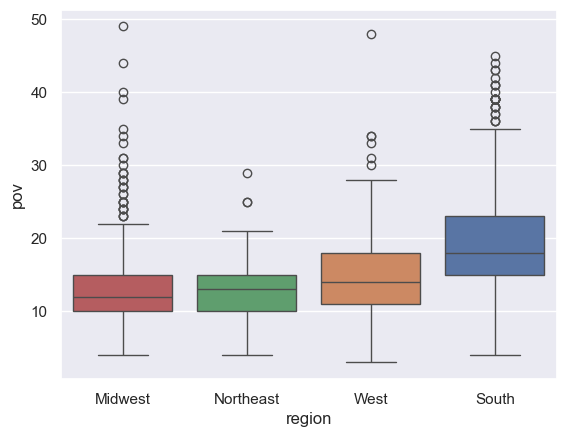

In [176]:
# Podemos ordenar las categorías pare mejorar la visualización
my_order = cty.groupby('region')['pov'].median().sort_values().index

sns.boxplot(data=cty, x='region', y='pov', hue='region', order=my_order);

### Variables asimétricas, transformación de variables

Muchos modelos estadísticos utilizados en política pública presuponen que las variables subyacentes se distribuyen normalmente.
Si no es así, existe la posibilidad de que las conclusiones no sean generalizables. Sin embargo, ya hemos observado que es bastante infrecuente que una variable se distribuya normalmente: muchas variables presentan cierta asimetría.

Muchas variables serán asimétricas a la izquierda (es decir, una larga cola a la izquierda con un pico a la derecha) o a la derecha (es decir, una larga cola a la derecha con un pico a la izquierda). Cualquier asimetría significa que una variable es asimétrica. Las variables muy asimétricas pueden ser difíciles de analizar, ya que la masa central de la distribución está comprimida en un área pequeña que es difícil de inspeccionar visualmente. Para distribuciones sesgadas a la derecha, considere aplicar una transformación logarítmica que tiene el efecto de comprimir la cola larga.
Una transformación de raíz cuadrada es mucho menos drástica y es capaz de distribuir la masa central de la distribución sobre un área mayor. Las distribuciones sesgadas a la izquierda (no mostradas) pueden transformarse elevando al cuadrado una variable.

In [18]:
cty.head()

,region,fips,state,name,ba,all.emp,pct.tech,est,pov,inc
0,South,1001,AL,Autauga County,24.593,10790,0.398517,0.235018,14.0,54487.0
1,South,1003,AL,Baldwin County,29.547,61341,0.386365,0.305635,12.0,56460.0
2,South,1005,AL,Barbour County,12.868,6857,0.000000,0.000000,30.0,32884.0
3,South,1007,AL,Bibb County,12.000,3387,0.000000,0.000000,20.0,43079.0
4,South,1009,AL,Blount County,13.050,6286,0.302259,0.296296,14.0,47213.0


/opt/homebrew/Caskroom/mambaforge/base/envs/popsynth/lib/python3.11/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


Text(0.5, 0, 'Log Percent')

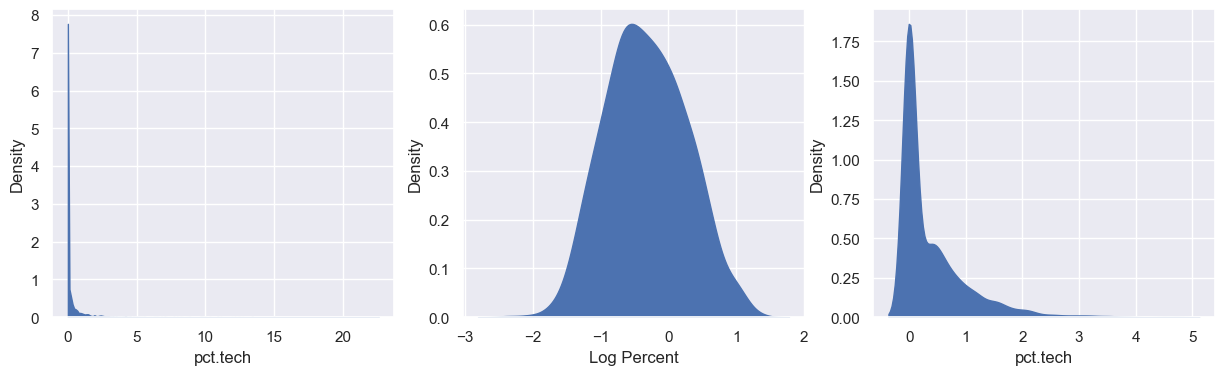

In [19]:
figure, ax = plt.subplots(1, 3, figsize=(15, 4))

sns.kdeplot(data=cty, x='pct.tech', ax=ax[0], fill=True, cut=0, bw_adjust=0.1, alpha=1)
sns.kdeplot(x=np.log10(cty['pct.tech']), ax=ax[1], fill=True, alpha=1)
sns.kdeplot(x=np.sqrt(cty['pct.tech']), ax=ax[2], fill=True, alpha=1)
ax[1].set_xlabel('Log Percent')

En la práctica, el principal uso de las transformaciones de variables es ajustar los datos para cumplir los supuestos de modelización. Se podría aplicar una transformación logarítmica a ciegas, ya que cualquier ajuste de los datos puede acercar o alejar arbitrariamente una variable de una distribución teórica ideal. Los gráficos cuantil-cuantil (gráficos QQ) ayudan a evaluar en qué medida una variable sigue una distribución teórica conocida (por ejemplo, la distribución normal) en cada cuantil.

In [20]:
import scipy.stats as stats

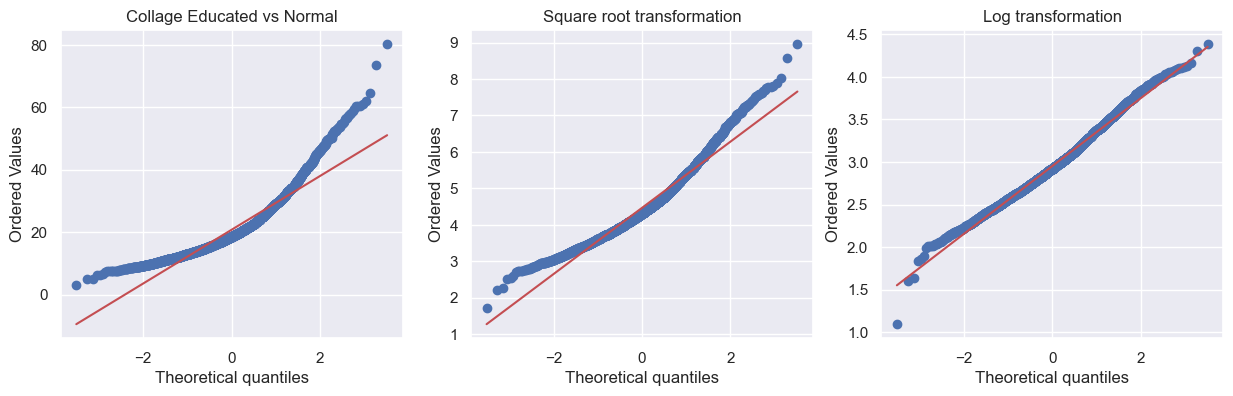

In [21]:
figure, ax = plt.subplots(1, 3, figsize=(15, 4))

stats.probplot(cty.ba, dist="norm", plot=ax[0])
stats.probplot(np.sqrt(cty.ba), dist="norm", plot=ax[1])
stats.probplot(np.log(cty.ba), dist="norm", plot=ax[2])

ax[0].set_title('Collage Educated vs Normal')
ax[1].set_title('Square root transformation')
ax[2].set_title('Log transformation');

En la Figura se compara el porcentaje de personas con estudios universitarios (eje vertical) con una distribución normal (distribución horizontal). La línea recta azul representa la línea de igualdad-cuando la tasa de educación coincide exactamente con una distribución normal teórica. Los puntos representan valores específicos de la tasa de educación universitaria y su correspondencia con el mismo cuantil de una distribución normal teórica. La distribución sin transformar sólo coincide con la distribución teórica en la masa central, mientras que los valores de las colas divergen. Al aplicar una transformación de raíz cuadrada, las colas se acercan más a la línea de igualdad, pero siguen sin alcanzar el objetivo, mientras que una transformación logarítmica es capaz de aproximarse a la distribución normal.
En todos los casos, las transformaciones de variables pueden mejorar las propiedades de una variable forzándola a parecer más "normal". Estos ajustes se producen a costa de un conjunto de variables menos intuitivo.

### Ejercicio:
Usa la base de diamantes y explora la distribución de las variables depth y price.

## Outliers o valores extremos

¿Cómo vemos a los outliers en nuestros plots?

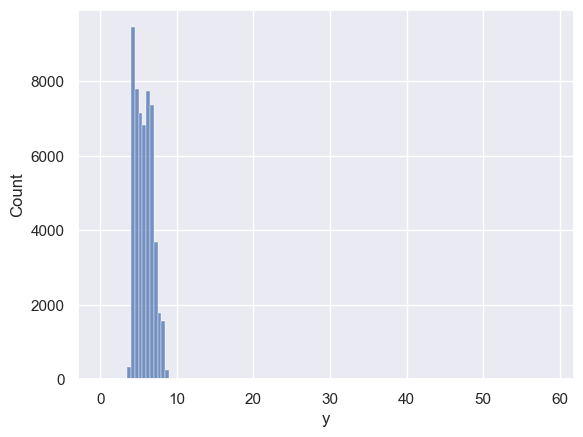

In [22]:
sns.histplot(data=diamonds, x='y', binwidth=0.5);

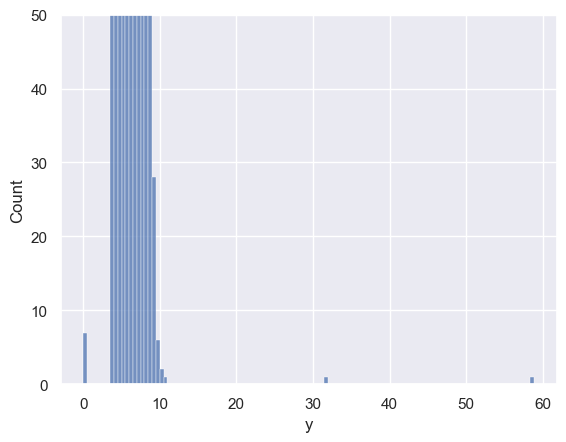

In [23]:
graph = sns.histplot(data=diamonds, x='y', binwidth=0.5)
graph.set(ylim = (0,50));

In [24]:
diamonds.y.describe()

count    53940.000000
mean         5.734526
std          1.142135
min          0.000000
25%          4.720000
50%          5.710000
75%          6.540000
max         58.900000
Name: y, dtype: float64

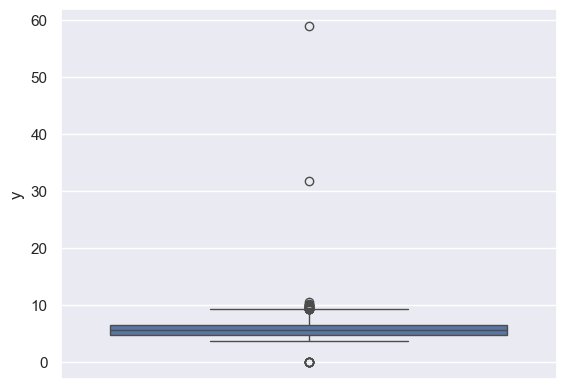

In [25]:
sns.boxplot(data=diamonds, y='y');

In [26]:
# ¿Qué pasa con estos valores extraños?
diamonds.query("y < 3 | y > 20")[['price', 'x', 'y', 'z']]

,price,x,y,z
11963,5139,0.00,0.0,0.00
15951,6381,0.00,0.0,0.00
24067,12210,8.09,58.9,8.06
24520,12800,0.00,0.0,0.00
26243,15686,0.00,0.0,0.00
27429,18034,0.00,0.0,0.00
49189,2075,5.15,31.8,5.12
49556,2130,0.00,0.0,0.00
49557,2130,0.00,0.0,0.00


¿Qué podemos hacer con estos valores extraños?
1. Tirarlos
2. Ponerlos como missing
3. Winsorize

In [27]:
# Tirarlos
diamonds[(diamonds.y >= 3) & (diamonds.y <= 20)]

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [28]:
# Volverlos Missing values
diamonds['y_nan'] = [
    np.nan if y < 3 or y > 20 else y
    for y in diamonds.y
]
diamonds[diamonds.y_nan.isnull()]

,carat,cut,color,clarity,depth,table,price,x,y,z,y_nan
11963,1.00,Very Good,H,VS2,63.3,53.0,5139,0.00,0.0,0.00,NaN
15951,1.14,Fair,G,VS1,57.5,67.0,6381,0.00,0.0,0.00,NaN
24067,2.00,Premium,H,SI2,58.9,57.0,12210,8.09,58.9,8.06,NaN
24520,1.56,Ideal,G,VS2,62.2,54.0,12800,0.00,0.0,0.00,NaN
26243,1.20,Premium,D,VVS1,62.1,59.0,15686,0.00,0.0,0.00,NaN
27429,2.25,Premium,H,SI2,62.8,59.0,18034,0.00,0.0,0.00,NaN
49189,0.51,Ideal,E,VS1,61.8,55.0,2075,5.15,31.8,5.12,NaN
49556,0.71,Good,F,SI2,64.1,60.0,2130,0.00,0.0,0.00,NaN
49557,0.71,Good,F,SI2,64.1,60.0,2130,0.00,0.0,0.00,NaN


In [29]:
# Winsorize
pct1, pct99 = diamonds.y.quantile([0.01, 0.99])
diamonds['y_winsor'] = [
    pct1 if y < pct1
    else(
        pct99 if y > pct99 else y
    ) for y in diamonds.y
]

# Puedes usar from scipy.stats.mstats import winsorize en vez de hacerlo a mano

diamonds[['y', 'y_winsor']].describe()

,y,y_winsor
count,53940.000000,53940.000000
mean,5.734526,5.731994
std,1.142135,1.104513
min,0.000000,4.040000
25%,4.720000,4.720000
50%,5.710000,5.710000
75%,6.540000,6.540000
max,58.900000,8.340000


- Minimiza la influencia de los outliers
- Buena idea cuando utilizamos algoritmos sensibles a outliers como la regresión lineal

¿Qué hacer con los valores extraños?
- ¿Cómo se que problema tengo? Examina todos los posibles datos extraños
- ¿Cómo decido que hacer con ellos? Idealmente, pregunta a quién hizo (o te dio) la base por qué esos valores son extraños
- Recuerda: nunca borrar datos de la base original, puedes agregar todo lo que quieras pero no elimines columnas/renglones/celdas
- Observación: En la vida real en cada columna vas a tener un de datos que no tengan nada de sentido. Si comienzas a tirar cada renglón con valores extraños en alguna columna, te vas a quedar sin base!

## Explorando valores faltantes

Los valores faltantes son una realidad del trabajo con el mundo real y plantean retos logísticos a los proyectos de datos.
La mayoría de las técnicas analíticas requieren registros de datos completos. La regresión lineal -una de las favoritas en política pública- sólo puede estimarse con muestras completas, por lo que la mayoría de las implementaciones sólo utilizarán registros completos. Muchos algoritmos de aprendizaje automático no podrán entrenar un modelo con ningún valor perdido. Si a todas las observaciones de un conjunto de datos les falta al menos un valor, entonces el valor de todo el conjunto de datos puede estar en peligro. Por este motivo, a veces se descartan los valores que faltan, mientras que otras veces se pueden imputar (es decir, rellenar con una aproximación). El tratamiento exacto de los valores perdidos depende de la comprensión de las cualidades de los mismos.

*Recuerda siempre revisar el diccionario de datos para conocer como se repesentan los datos faltantes. No es lo mismo un dato faltante, que un "No aplica" o un cero.*

Pandas maneja los valores faltantes de dos maneras. La primera ya la has visto en secciones anteriores: `NaN`, o Not a Number. Este es en realidad un valor especial que forma parte de la especificación IEEE de punto flotante y sólo se utiliza para indicar valores de punto flotante que faltan.

Para valores que faltan aparte de los flotantes, pandas utiliza el objeto `None` de Python. Debido a que `None` proviene de Python, no se puede utilizar en arrays de NumPy y pandas que no sean del tipo de datos `'object'`.

In [30]:
print(np.array([2, None, 6, 8]).dtype)  # Las operaciones con None son lentas (Python nativo)
print(np.array([2, np.nan, 6, 8]).dtype)  # Operaciones compildas de numpy

object
float64


In [31]:
# print(np.array([2, None, 6, 8]).sum())  # No funciona
print(np.array([2, np.nan, 6, 8]).sum())

nan


### Funciones para valores faltantes

Algunos de los métodos que se utilizan para tratar con valores perdidos en pandas reflejan esta idea en sus nombres:

- `isnull()`: Genera una máscara booleana que indica valores perdidos
- `notnull()`: Lo contrario de `isnull()`.
- `dropna()`: Devuelve una versión filtrada de los datos
- `fillna()`: Devuelve una copia de los datos con los valores perdidos rellenados o imputados

In [32]:
hourly_wage = pd.Series([14, 15, None, 15, 20, np.nan, -99, np.inf])
hourly_wage

0    14.0
1    15.0
2     NaN
3    15.0
4    20.0
5     NaN
6   -99.0
7     inf
dtype: float64

In [33]:
hourly_wage.isna()
hourly_wage.isnull()
np.isinf(hourly_wage)
hourly_wage.isnull().any()  # Al menos un nulo
hourly_wage.isnull().sum()  # Cuenta los nulos
hourly_wage.isnull().mean()  # Calcula la proporción de nulos

0.25

In [34]:
hourly_wage.replace(-99, np.nan).isnull().sum()

3

In [35]:
hourly_wage.replace(np.inf, 10).sum()  # Pandas ingnora nans
hourly_wage.replace(np.inf, 10).values.sum()  # Numpy no
np.nansum(hourly_wage.replace(np.inf, 10).values)

-25.0

### Analizando datos faltantes

Rubin (1976) establece distintos tipos de omisión. Cada tipo tiene una definición y propiedades estadísticas específicas y, a su vez, debe tratarse de forma diferente. En algunos casos, centrarse en los valores completos puede sesgar el análisis, ya que la omisión es sistemática. En otros casos, la omisión es completamente aleatoria y no afecta negativamente al análisis. A continuación se describen los distintos grados de omisión,
no en todo su esplendor estadístico, sino a un alto nivel conceptual:

- *Missing Completely at Random* (MCAR): Cuando los valores perdidos no están correlacionados con las variables observadas en los datos. Por ejemplo, el patrón de falta de respuesta a una pregunta de la encuesta sobre los ingresos no está correlacionado con otras variables captadas en la encuesta, como el nivel educativo o la pobreza. Cuando los datos son MCAR, no es probable que los valores perdidos sesguen el análisis.

- *Missing at Random* (MAR): Cuando los valores perdidos dependen de variables observadas en el conjunto de datos. Por ejemplo, la falta de respuesta a una pregunta sobre ingresos está correlacionada con el nivel educativo de los encuestados. Cuando los datos son MAR, los valores que faltan pueden dar lugar a un análisis sesgado si no se tratan o ajustan.

- *Missing Not at Random* (MNAR): Cuando los valores perdidos están correlacionados con el concepto que se mide y además no cumplen ninguno de los criterios de MCAR y MAR. Por ejemplo, los encuestados no responden a la pregunta sobre los ingresos si tienen ingresos más altos. En estos casos, un investigador no puede identificar directamente las razones del MNAR y, en su lugar, requiere una profunda experiencia en la materia para identificar los mecanismos precisos que causan la omisión.

In [36]:
# Simulemos dantos faltantes al azar (MCAR)
cty_mcar = cty.copy()
cty_mcar.loc[np.random.uniform(size=cty_mcar.shape[0]) < 0.5, 'ba'] = np.nan

# Create column with dumme variables
cty_mcar['missing'] = cty_mcar.ba.notnull()

print(stats.ttest_ind(cty_mcar.inc[cty_mcar.missing], cty_mcar.inc[~cty_mcar.missing]).pvalue)
print(stats.ttest_ind(cty_mcar.pov[cty_mcar.missing], cty_mcar.pov[~cty_mcar.missing]).pvalue)
stats.chi2_contingency(pd.crosstab(cty_mcar.region, cty_mcar.missing)).pvalue

0.6647671524025873
0.9621732387986902


0.7913590463560164

Como ninguna de las pruebas es significativa en ninguno de los niveles estándar (por ejemplo, 1%, 5% o 10%), podemos deducir que los valores se han perdido de forma totalmente aleatoria.

In [37]:
# Simulemos datos faltantes de acuerdo a MAR
# Los datos faltantes solo aparece para bajo ingreso

cty_mar = cty.copy()
cty_mar.loc[
    (np.random.uniform(size=cty_mar.shape[0]) < 0.5) & (cty_mar.inc < 41073),
    'ba'] = np.nan

# Create column with dumme variables
cty_mar['missing'] = cty_mar.ba.notnull()

print(stats.ttest_ind(cty_mar.inc[cty_mar.missing], cty_mar.inc[~cty_mar.missing]).pvalue)
print(stats.ttest_ind(cty_mar.pov[cty_mar.missing], cty_mar.pov[~cty_mar.missing]).pvalue)
stats.chi2_contingency(pd.crosstab(cty_mar.region, cty_mar.missing)).pvalue

1.3293552462046234e-110
3.512716760254399e-158


3.548773620077181e-32

Las pruebas de hipótesis confirman la presencia de dependencia, ya que
todas las pruebas arrojan resultados estadísticamente significativos al nivel del 1%. Esta conclusión no debería sorprender, ya que
la renta, la situación socioeconómica y la geografía están intrínsecamente interrelacionadas. Dado que el patrón de valores perdidos
está correlacionado con otras variables, podemos deducir que los valores sólo faltan al azar.

### Tratamiento de los datos que faltan


|Opción de tratamiento |Descripción| MCAR |MAR|
|-|-|-|-|
|Listwise deletion |Elimine cualquier registro en el que falte un valor. También conocido como análisis de caso completo. | x| |
|Drop variable |Elimina las variables con valores perdidos. Más apropiado cuando el número de valores perdidos es bastante grande y se concentra en una variable. | x| x|
|Mean or median imputation | Sustituya los valores que faltan por la media o la mediana de la variable. La media es adecuada para distribuciones continuas simétricas, mientras que la media es adecuada para variables continuas sesgadas.| x| |
|Mode imputation |Sustituir los valores que faltan por la moda de la variable - apto para variables discretas. | x| |
|Model-based imputation |Impute los valores que faltan utilizando un modelo de predicción como los árboles de regresión o k-Nearest Neighbors (kNN). Los modelos aprovechan las correlaciones observadas entre los casos completos para aproximar los valores que faltan. | x| x|
|Multiple imputation |Imputar utilizando imputaciones basadas en modelos, haciéndolo varias veces y luego promediando los resultados para eliminar posibles sesgos. | x| x|

In [38]:
# Eliminar valores faltantes
cty_mcar.dropna()

,region,fips,state,name,ba,all.emp,pct.tech,est,pov,inc,missing
0,South,1001,AL,Autauga County,24.593,10790,0.398517,0.235018,14.0,54487.0,True
3,South,1007,AL,Bibb County,12.000,3387,0.000000,0.000000,20.0,43079.0,True
8,South,1017,AL,Chambers County,12.484,6276,0.796686,0.000000,20.0,39530.0,True
9,South,1019,AL,Cherokee County,13.962,3905,0.000000,0.000000,17.0,41456.0,True
13,South,1027,AL,Clay County,11.063,3277,0.000000,0.000000,19.0,38512.0,True
...,...,...,...,...,...,...,...,...,...,...,...
3122,West,56017,WY,Hot Springs County,22.336,1587,0.000000,0.000000,14.0,46024.0,True
3123,West,56019,WY,Johnson County,25.463,2341,0.555318,1.070664,9.0,56323.0,True
3127,West,56027,WY,Niobrara County,18.991,413,0.000000,0.000000,14.0,45332.0,True
3130,West,56033,WY,Sheridan County,30.125,10392,0.644727,0.509338,9.0,53027.0,True


El comando dropna de pandas puedo ajustar su comportamiento usando los parámetros axis, how y tresh.
Con axis podemos pedir que elimine columnas en ligar de filas, y tresh ajusta el mínimo número de valores faltantes que resulta en la eliminación la fila o columna. Generemos un dataset sintético para mostrar su funcionamiento.

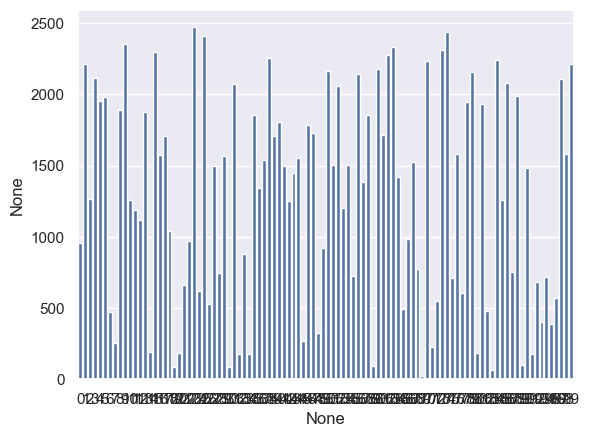

In [39]:
n = 10000 # filas
k = 100 # columnas
pct_miss = 0.25 # porcentaje de valores faltantes

df = pd.DataFrame(np.random.normal(size=(n,k)))
for i in range(k):
    df.loc[np.random.uniform(size=n) <= np.random.uniform(0, pct_miss), i] = np.nan
sns.barplot(x=df.columns, y=df.isnull().sum(axis=0));

In [40]:
thresh_ar = np.linspace(0.01, 0.99, 100)
ncols_list = []
comp_rows_list = []
for thresh in thresh_ar:
    df_drop = df.dropna(thresh=thresh*n, axis=1)
    ncols = df_drop.shape[1]
    comp_rows = (df_drop.isna().mean(axis=1) == 0).sum()
    ncols_list.append(ncols)
    comp_rows_list.append(comp_rows)

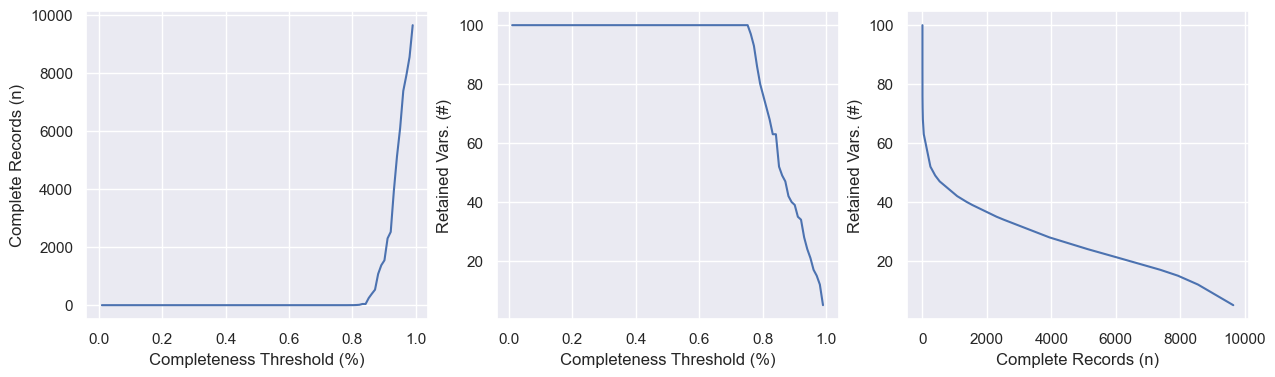

In [41]:
figure, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].plot(thresh_ar, comp_rows_list)
ax[0].set_xlabel('Completeness Threshold (%)')
ax[0].set_ylabel('Complete Records (n)')

ax[1].plot(thresh_ar, ncols_list)
ax[1].set_xlabel('Completeness Threshold (%)')
ax[1].set_ylabel('Retained Vars. (#)')

ax[2].plot(comp_rows_list, ncols_list)
ax[2].set_xlabel('Complete Records (n)')
ax[2].set_ylabel('Retained Vars. (#)');

### Imputación de valores faltantes

Los enfoques más sencillos implican la imputación de la media o la mediana, que son apropiadas para cuando los datos son
MCAR. Imputar la media o mediana preserva esa propiedad pero cambia la distribución de los datos.

In [42]:
cty_mcar['ba_mean'] = cty_mcar.ba.fillna(cty_mcar.ba.mean())
cty_mcar['ba_med'] = cty_mcar.ba.fillna(cty_mcar.ba.median())

Sin embargo, cuando los datos son MAR, podemos aumentar la sofisticación de nuestras imputaciones aprovechando las técnicas de imputación basadas en modelos que exponen las correlaciones entre los valores que faltan y otras variables.
Vamos a tratar varios modelos predictivos que podrían usarse para imputar más adelante, en particular bosques aleatorios han demostrado buenos resultados cuando se usan para imputar (por ejemplo, missForest). Para demostrar rapidamente este tipo de imputación usaremos un modelo de vecinos más cercanos.

In [49]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=2, weights="uniform")
cty_filled = pd.DataFrame(
        imputer.fit_transform(cty_mar.drop(columns=['region', 'fips', 'state', 'name', 'missing'])),
        columns=['ba', 'all.emp', 'pct.tech', 'est', 'pov', 'inc'])
cty_filled

,ba,all.emp,pct.tech,est,pov,inc
0,24.593,10790.0,0.398517,0.235018,14.0,54487.0
1,29.547,61341.0,0.386365,0.305635,12.0,56460.0
2,12.175,6857.0,0.000000,0.000000,30.0,32884.0
3,12.000,3387.0,0.000000,0.000000,20.0,43079.0
4,13.050,6286.0,0.302259,0.296296,14.0,47213.0
...,...,...,...,...,...,...
3132,21.371,16419.0,0.170534,0.000000,10.0,74546.0
3133,53.788,17864.0,0.845275,0.855107,7.0,84118.0
3134,18.207,6990.0,0.100143,0.349040,11.0,64713.0
3135,21.076,2828.0,0.000000,0.558659,13.0,49533.0


¿Cómo se comparan todas estas técnicas de imputación? En la Figura, evaluamos lo bien que cada método de imputación es capaz de aproximarse a la distribución ba original.
Para el conjunto de datos MCAR, las imputaciones de la media y la mediana
conservan cualidades específicas (por ejemplo, la tendencia central) al tiempo que distorsionan la forma de la distribución.
En cambio, la imputación basada en modelos aplicada al conjunto de datos MAR se aproxima mejor a la forma de la distribución original. Aunque los enfoques basados en modelos
pueden aplicarse tanto a conjuntos de datos MCAR como MAR, los conjuntos de datos MAR son mucho más adecuados dada la presencia de correlaciones que pueden explotarse.

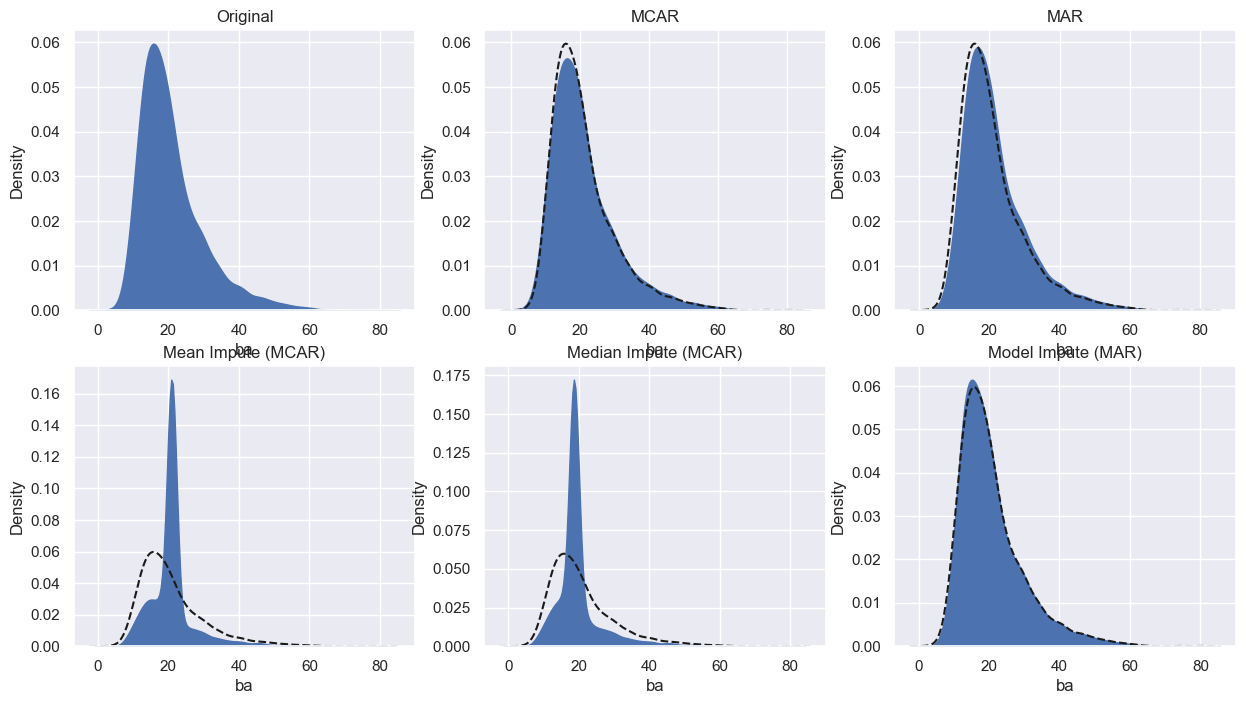

In [65]:
fig, ax = plt.subplots(2, 3, figsize=(15, 8))

sns.kdeplot(data=cty, x='ba', fill=True, alpha=1, ax=ax[0, 0])
ax[0, 0].set_title('Original')

sns.kdeplot(data=cty, x='ba', fill=False, ax=ax[0, 1], linestyle="--", color='k')
sns.kdeplot(data=cty_mcar, x='ba', fill=True, alpha=1, ax=ax[0, 1])
ax[0, 1].set_title('MCAR')

sns.kdeplot(data=cty, x='ba', fill=False, ax=ax[0, 2], linestyle="--", color='k')
sns.kdeplot(data=cty_mar, x='ba', fill=True, alpha=1, ax=ax[0, 2])
ax[0, 2].set_title('MAR')

sns.kdeplot(data=cty, x='ba', fill=False, ax=ax[1, 0], linestyle="--", color='k')
sns.kdeplot(data=cty_mcar, x='ba_mean', fill=True, alpha=1, ax=ax[1, 0])
ax[1, 0].set_title('Mean Impute (MCAR)')

sns.kdeplot(data=cty, x='ba', fill=False, ax=ax[1, 1], linestyle="--", color='k')
sns.kdeplot(data=cty_mcar, x='ba_med', fill=True, alpha=1, ax=ax[1, 1])
ax[1, 1].set_title('Median Impute (MCAR)')

sns.kdeplot(data=cty, x='ba', fill=False, ax=ax[1, 2], linestyle="--", color='k')
sns.kdeplot(data=cty_filled, x='ba' , fill=True, alpha=1, ax=ax[1, 2])
ax[1, 2].set_title('Model Impute (MAR)');

## Series de tiempo

Muchos conjuntos de datos son series temporales que registran información a lo largo de intervalos regulares de tiempo. Básicamente, todas las cotizaciones bursátiles, los datos económicos, los datos meteorológicos y los sensores físicos son series temporales. Las series temporales son especiales, ya que su naturaleza secuencial dicta cómo se debe trabajar con los datos. Hay ciertos tipos de gráficos que se adaptan mejor a las series temporales.

Trazamos el número total de contenedores contenedores que pasaron por el puerto de Long Beach, en California.

In [68]:
polb = pd.read_csv('../data/polb.csv', parse_dates=[0])
polb.head()

,date,loaded.inbound,loaded.outbound,total.loaded,empties,total
0,1995-01-01,104774.0,74091.0,178865.0,36030.0,214895.0
1,1995-02-01,99121.0,81879.0,181000.0,35102.0,216102.0
2,1995-03-01,94125.0,83964.0,178089.0,28349.0,206438.0
3,1995-04-01,110518.0,86879.0,197397.0,29534.0,226931.0
4,1995-05-01,113688.0,91226.0,204914.0,35462.0,240376.0


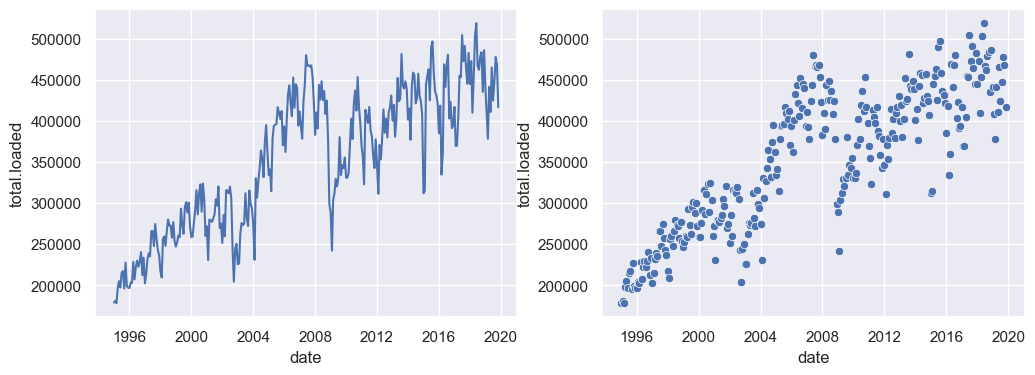

In [77]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.lineplot(polb, x='date', y='total.loaded', ax=ax[0])
sns.scatterplot(polb, x='date', y='total.loaded', ax=ax[1]);

Dado que las series temporales tienen una estructura especial, podemos analizar las capas de información que contienen. Una serie temporal (Y ) puede descomponerse en tres componentes:

$$Y = T + S + R$$

Donde T es una tendencia, la dirección predominante de los datos, S es la estacionalidad o los patrones que se repiten en un intervalo regular (por ejemplo, la estacionalidad mensual) y R es el componente de ruido (a veces denominado "irregular" o "residual"), la información sobrante que no se explica por la tendencia o la estacionalidad. Las series temporales brutas, como los volúmenes de contenedores POLB, no se ajustan estacionalmente (NSA), conservando todos los componentes de una serie temporal, como lo demuestran los picos y las depresiones que se producen en un ciclo anual regular.

La librería statsmodels de Python implementa dos algoritmos para descomponer series de tiempo. `seasonal_decompose` puede extrater una componente estacional estacionario en el tiempo, esto es, sus características no cambian en el tiempo. `STL` es un algoritmo más avanzando que puede extraer una componente estacional que evoluciona con el paso del tiempo. Por supuesto, el rendimiento de ambos algoritmos está sujeto a las suposiciones que hagamos sobre la periodicidad y características de la componente estacional que buscamos extraer.

In [97]:
from statsmodels.tsa.seasonal import STL, seasonal_decompose

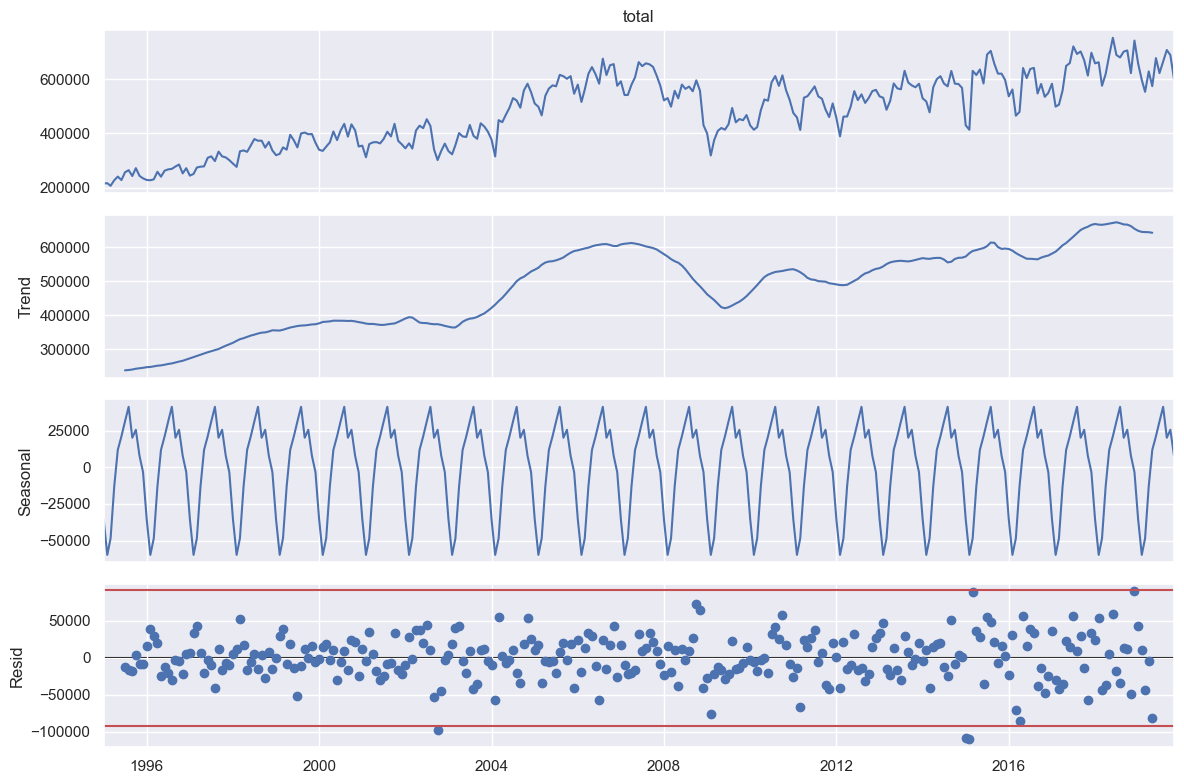

In [138]:
sd = seasonal_decompose(polb.set_index('date')['total'], period=12)

fig = sd.plot()
fig.set_size_inches((12, 8))

# Agregamos lineas a 3 std para detectar outliers
res_std = sd.resid.std()
fig.axes[3].axhline(3*res_std, color='r')
fig.axes[3].axhline(-3*res_std, color='r')


# Tight layout to realign things
fig.tight_layout();

In [136]:
sd.seasonal.min(), sd.seasonal.max()

(-59825.284118357486, 41431.1985205314)

Suponiendo una estacionalidad constante, el volumen mensual de contenedores puede oscilar entre -59.000 (febrero) y +41.000 (agosto) con respecto a la tendencia, o un rango de aproximadamente 100.000 contenedores a lo largo de un año. Una inspección más detallada del componente de ruido muestra grandes picos y caídas, algunos de los cuales parecen sospechosamente grandes: ¿Existen posibles valores atípicos, especialmente en 2002 y 2015?

De hecho, los valores atípicos hipotéticos se sitúan justo al otro lado de las vallas, lo que facilita el aislamiento de los valores atípicos: La caída de los volúmenes de contenedores en 2002 y 2015 se produce durante los conflictos laborales portuarios.

Otra función interesante para trabajar con series de tiempo es resample. Resample es como groupby sobre indices de tipo date.

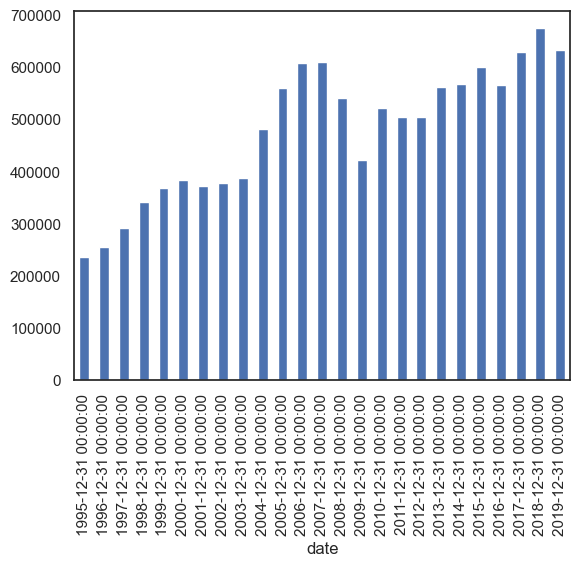

In [303]:
polb = polb.set_index('date')
polb.total.resample("1Y").mean().plot.bar();

## Correlaciones

Además de detectar patrones visualmente, EDA es útil para encontrar relaciones entre variables. La política y los responsables de la toma de decisiones disponen de un tiempo limitado y sólo pueden centrarse en un conjunto reducido de factores importantes. Para ayudar a estructurar el espacio del problema, los gráficos bivariantes simples son una opción eficaz para identificar correlaciones.

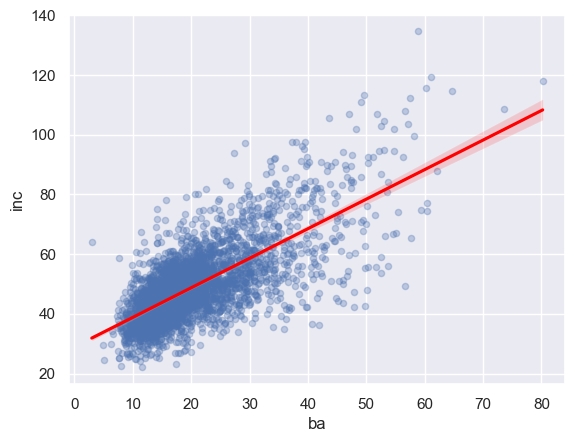

In [160]:
# Usa alpha y size para reducir la oclusión de puntos muy cercanos

sns.regplot(x=cty['ba'], y=cty['inc']/1000, scatter_kws={'alpha':0.3, 's':20}, line_kws={'color': 'red'});

La forma de las nubes de puntos son buenas aproximaciones de las correlaciones.
El coeficiente de correlación de Pearson es la métrica estándar para medir la fuerza y la dirección de la relación entre dos variables, X e Y .
Se obtiene dividiendo la covarianza (cov(X, Y )) por el producto de las desviaciones típicas σX y σY :

$$
\rho_{X,Y} = \frac{cov(X,Y)}{\sigma_X \sigma_Y} = \frac{\sum_{i=1}^n(X_i - \mu_X)(Y_i - \mu_Y)}{\sqrt{\sum_{i=1}^n(X_i - \mu_X)^2\sum_{i=1}^n(Y_i - \mu_Y)^2}}
$$

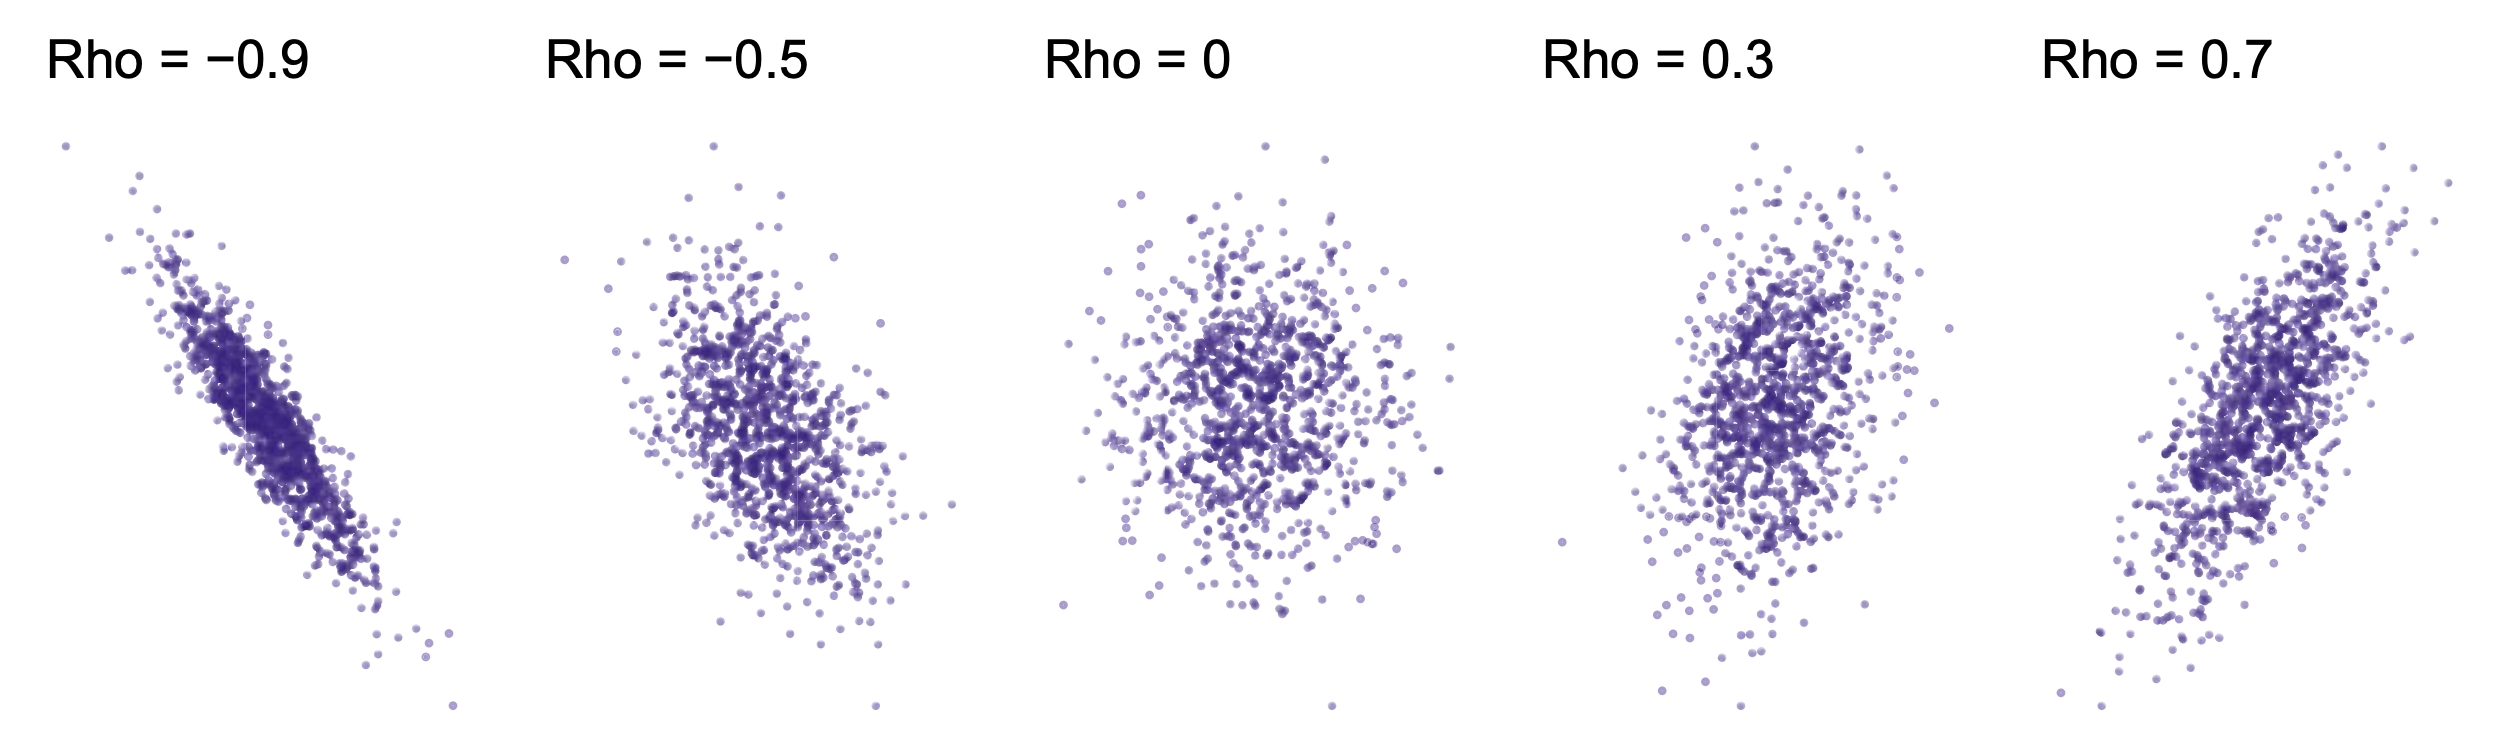

Otra opción es el joinplot que nos permite visualizar las distribuciones individuales de las dos variables.

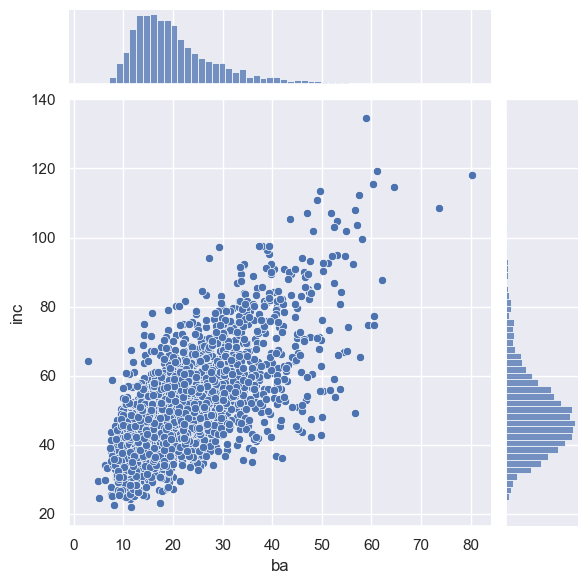

In [218]:
sns.jointplot(x=cty['ba'], y=cty['inc']/1000);
#sns.jointplot(x=cty['ba'], y=cty['inc']/1000, kind='hist');
#sns.jointplot(x=cty['ba'], y=cty['inc']/1000, kind='kde');
#sns.jointplot(x=cty['ba'], y=cty['inc']/1000, kind='reg');

Y también podemos condicionar en otra variable categórica.

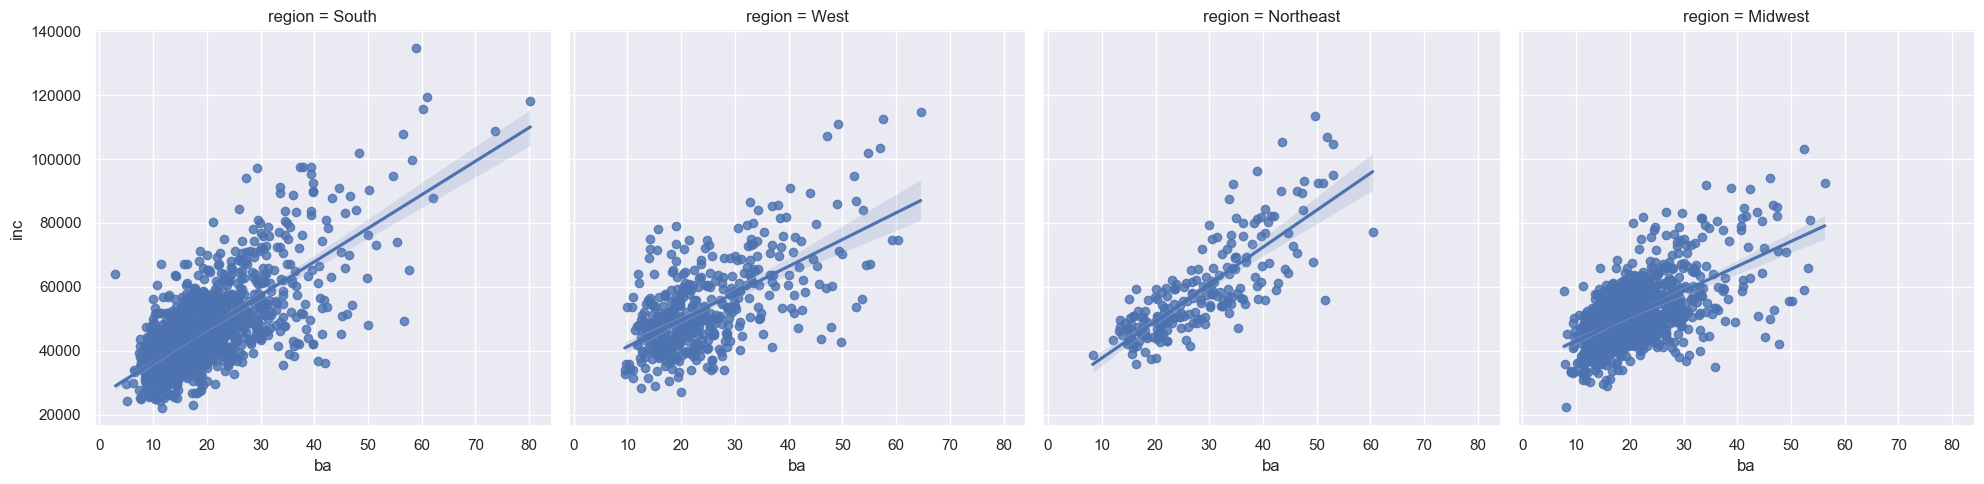

In [184]:
#sns.lmplot(cty, x='ba', y='inc', hue='region')
sns.lmplot(cty, x='ba', y='inc', col='region');

Observe que los gráficos anteriores son ejemplos de relaciones lineales bien definidas. Cuando la forma de un gráfico no sea la de una línea "difusa", siga investigando, ya que puede haber otras fuerzas en juego.

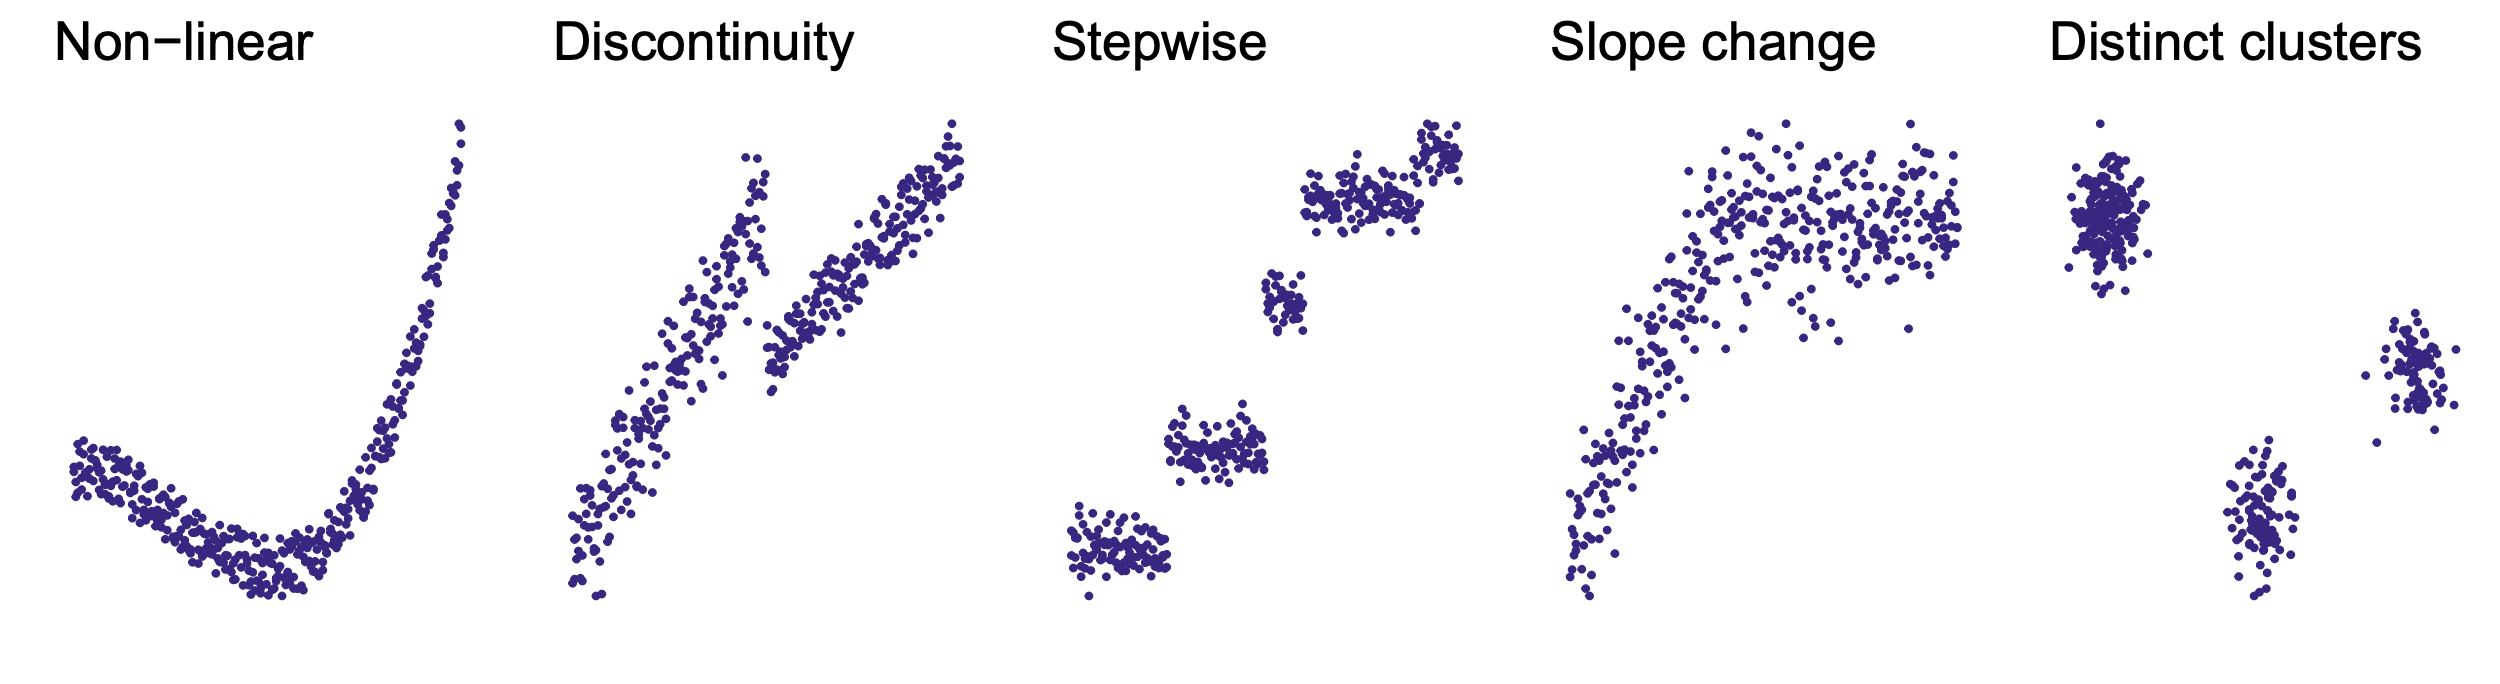

Para dos variables categóricas podemos usar un mapa de calor.

In [188]:
cty['inc_q'] = pd.qcut(cty.inc, q=10)
pd.crosstab(cty.region, cty.inc_q)

inc_q,"(22044.999, 35670.0]","(35670.0, 39446.0]","(39446.0, 42281.4]","(42281.4, 45093.4]","(45093.4, 47589.0]","(47589.0, 50384.8]","(50384.8, 53471.6]","(53471.6, 57416.8]","(57416.8, 65059.8]","(65059.8, 134609.0]"
region,,,,,,,,,,
Midwest,29,44,74,111,115,146,173,145,139,78
Northeast,0,5,7,16,20,26,20,30,38,55
South,264,235,192,152,137,83,84,93,76,105
West,21,30,40,35,42,58,37,45,61,76


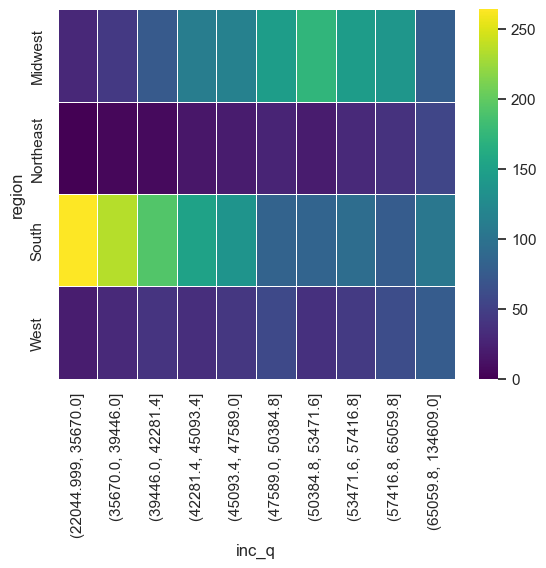

In [192]:
sns.heatmap(pd.crosstab(cty.region, cty.inc_q), cmap='viridis', linewidths=0.5);

O construir una gráfica de barras.

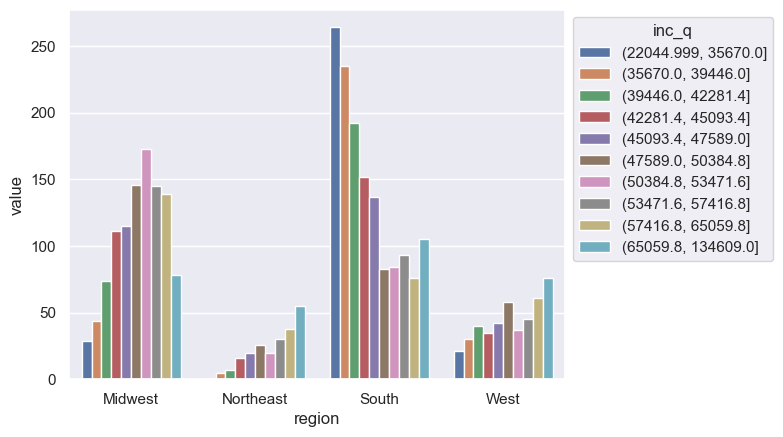

In [207]:
ax = sns.barplot(pd.crosstab(cty.region, cty.inc_q).reset_index().melt(id_vars='region'), x='region', y='value', hue='inc_q')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1));

#### Ejercicio
- Muestra la relación entre clarity y color
- ¿Qué pareja de claridad y color tiene más diamantes?
- Muestra la relación entre depth y price
- ¿Qué clase de gráfica crees que muestra mejor está relación?

### Datos de mayor dimensionalidad

Ilustramos visualizaciones para muchas variables utilizando el conjunto de datos en tiempo real para macroeconomistas del Banco de la Reserva Federal de Filadelfia (Banco de la Reserva Federal de Filadelfia 2019). El conjunto de datos cuenta con 59 variables métricas muy importantes, como el número de viviendas iniciadas en Estados Unidos (hstarts) y los índices de producción industrial (ipt e ipm)

In [229]:
econ_vintage = pd.read_csv('../data/econ_vintage.csv').set_index('date')
# econ_vintage.info()

In [230]:
# Obtenemos la matriz de correlación
corr = econ_vintage.corr()

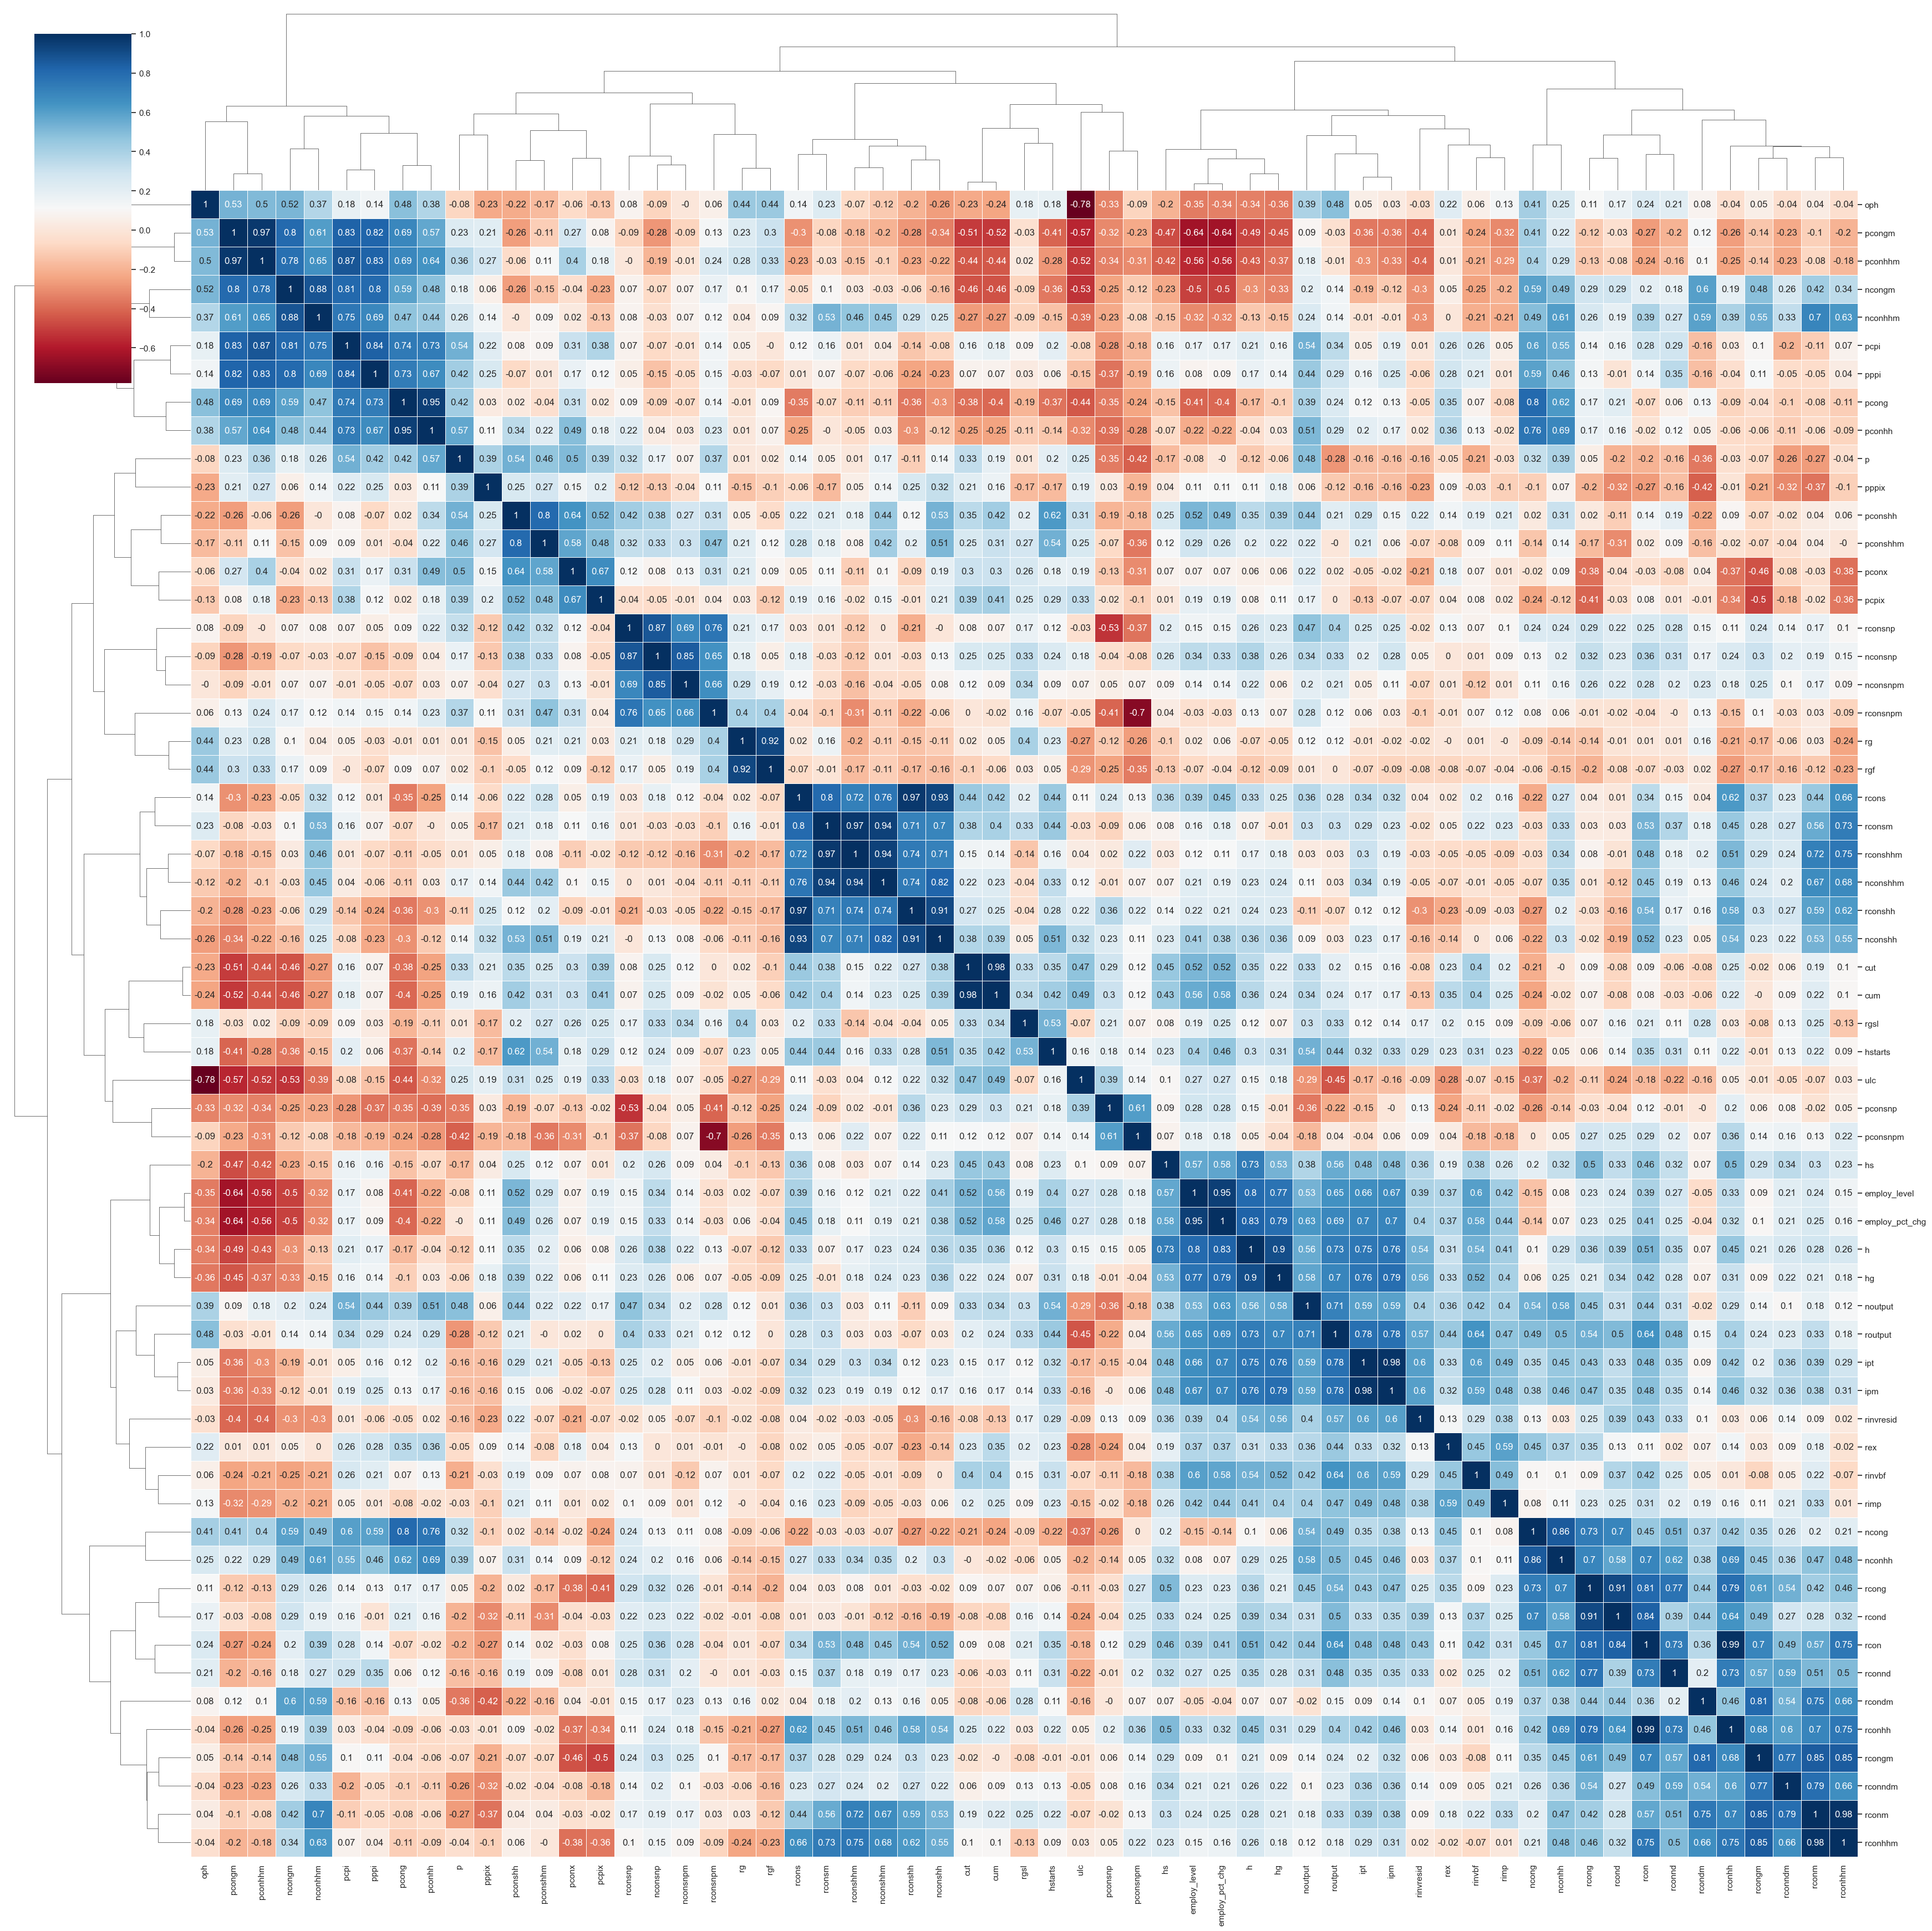

In [ ]:
sns.clustermap(round(corr, 2), method="complete", cmap='RdBu', figsize=(35, 35), annot=True, linewidths=.5, dendrogram_ratio=(.1, .1));

En lugar de revisar cada relación bivariable de una en una, los pairplots resumen de forma concisa los patrones univariables y bivariables en una matriz gráfica.

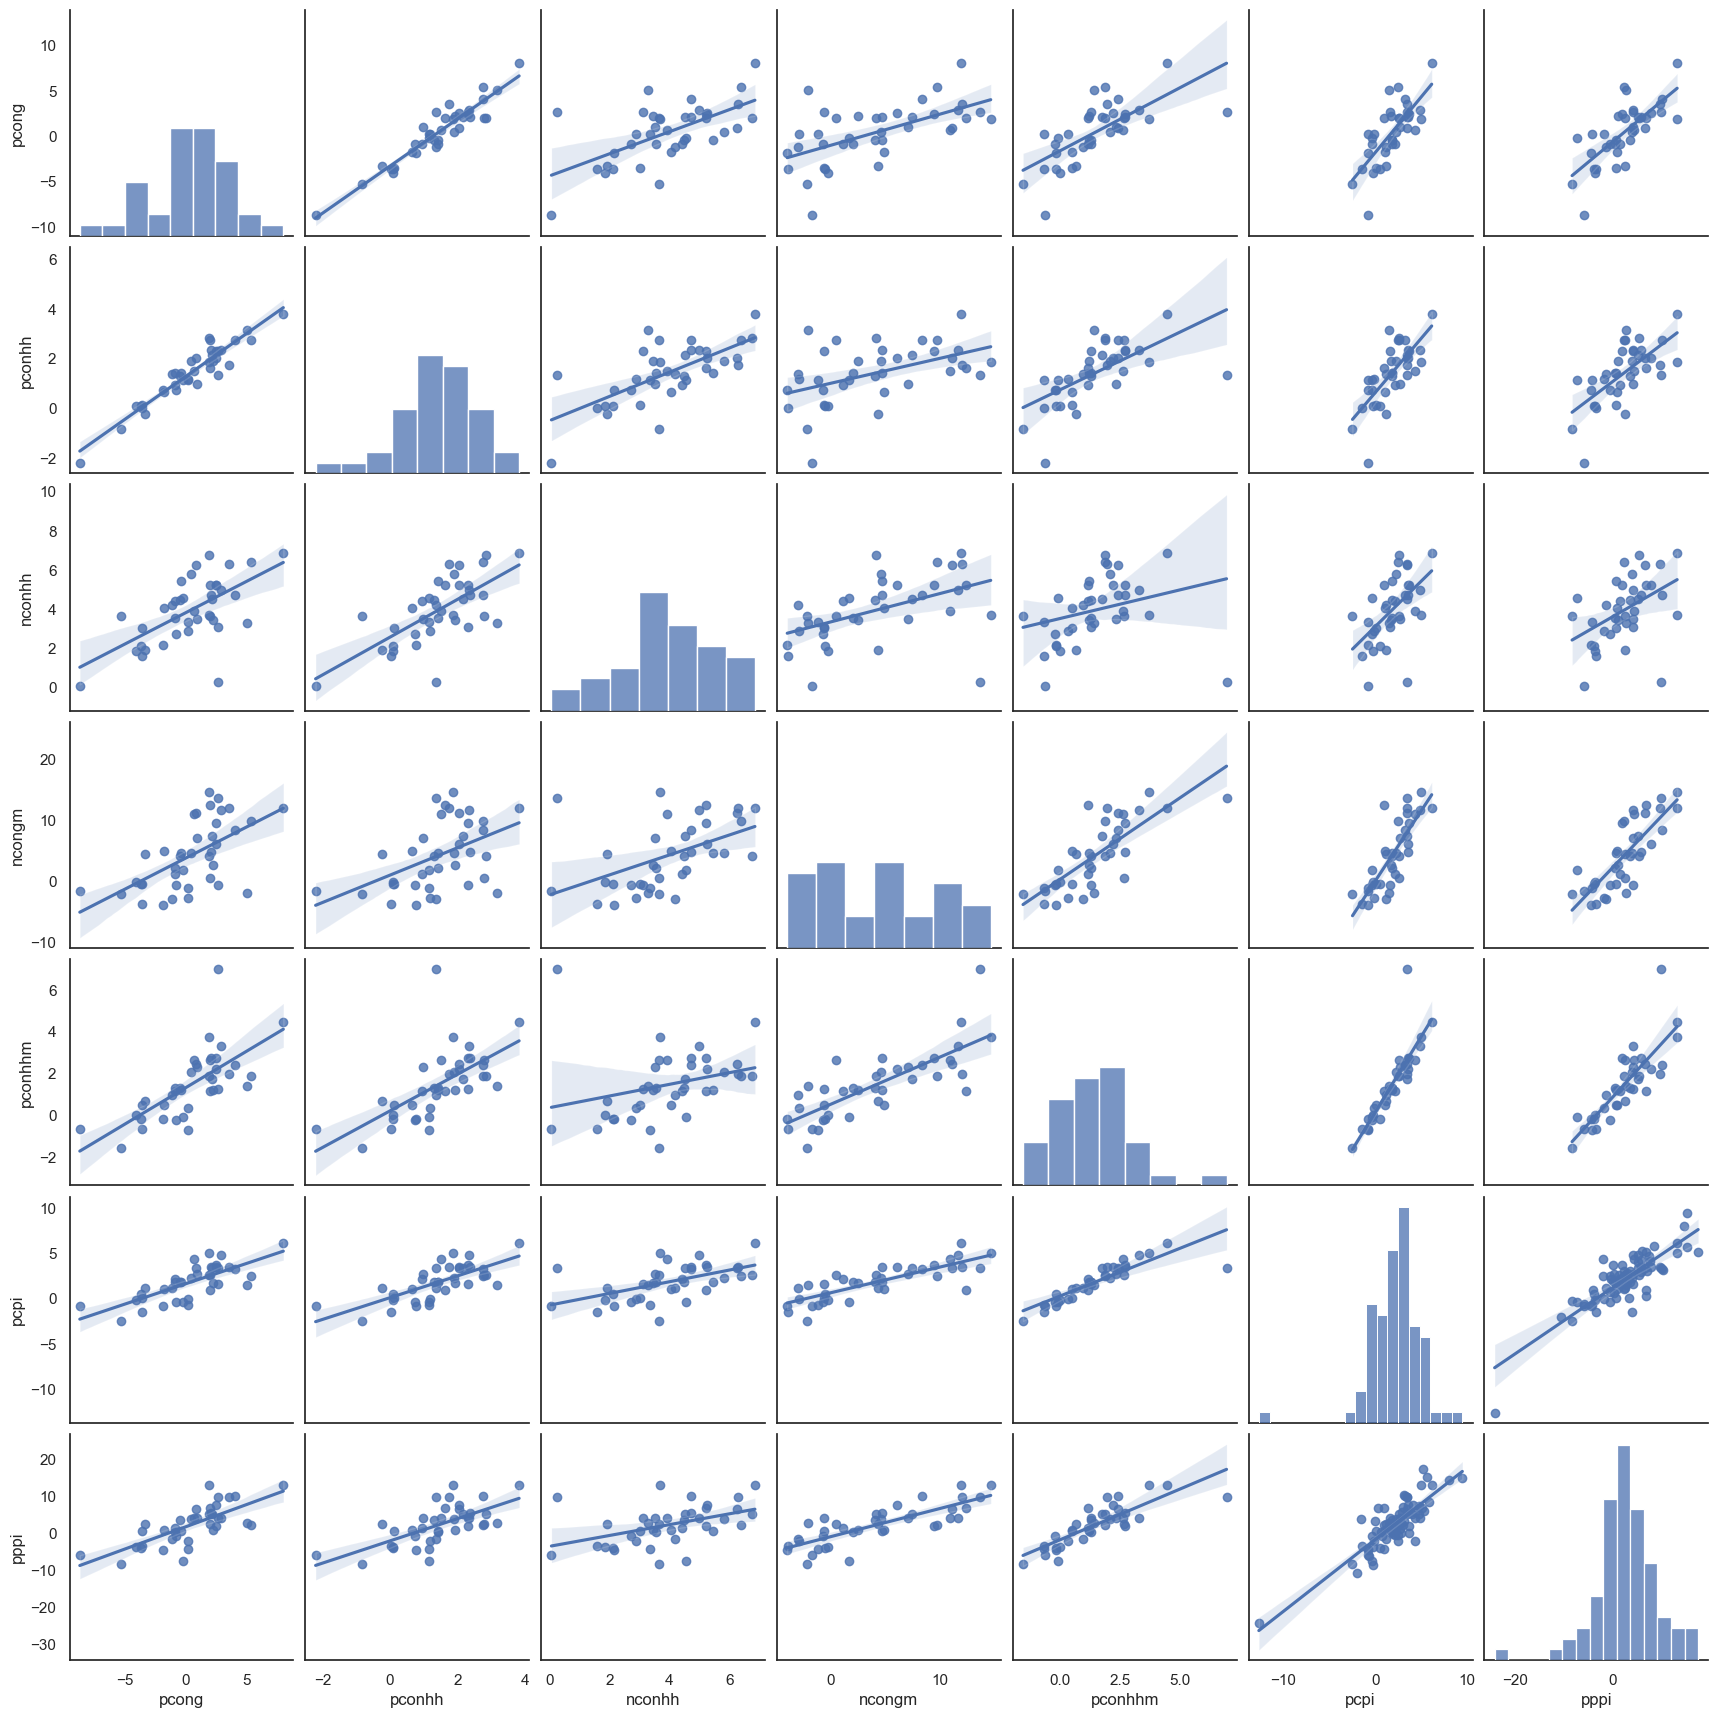

In [291]:
sns.pairplot(data=econ_vintage[["pcong", "pconhh", "nconhh", "ncongm", "pconhhm", "pcpi", "pppi"]], kind='reg');

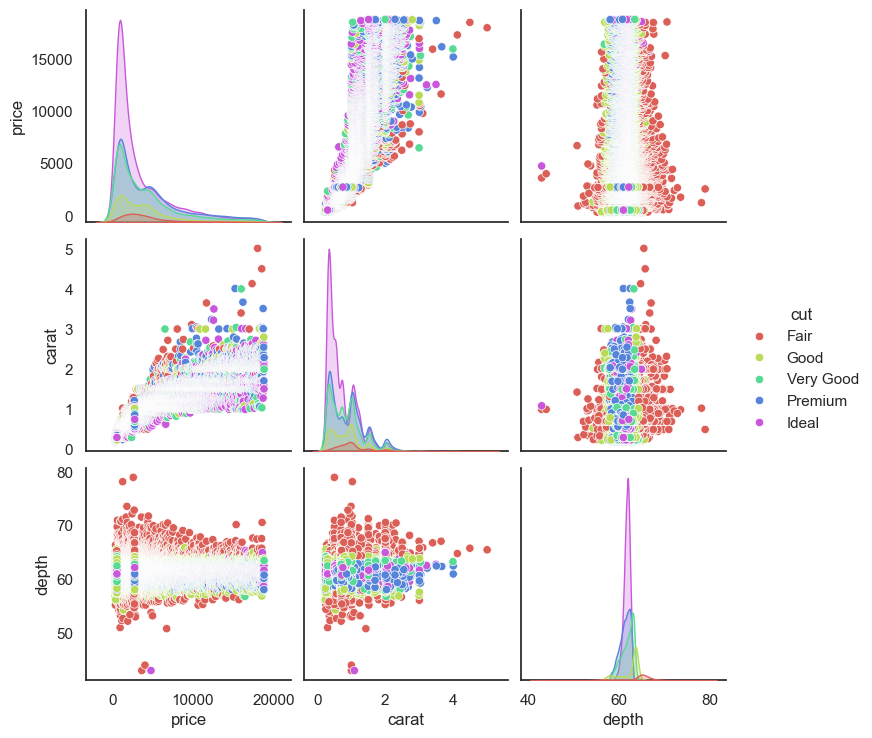

In [294]:
sns.pairplot(diamonds[['price', 'carat', 'depth','cut']], hue = 'cut', palette = 'hls');